# 1st Kr NEXT-100 data look

## Run 15502 - compare Kr maps (LT map, 3D, LT - unique)

01/08/25

In [2]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

## Configuration

In [3]:
import re
import glob
from collections import namedtuple

import sys
pypaths= ("/Users/hernando/work/investigacion/NEXT/software/nextana",
         "/Users/hernando/work/investigacion/NEXT/software/hipy",
         "/Users/hernando/work/investigacion/NEXT/software/IC")
for ipypath in pypaths:
       sys.path.insert(0,ipypath)

In [4]:
import numpy             as np
import pandas            as pd
import tables            as tb
from   scipy             import stats
from   scipy             import optimize

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d

plt.rcParams['image.cmap'] = 'rainbow'

In [5]:
from invisible_cities.io.dst_io import load_dst, load_dsts

In [6]:
import hipy.utils        as ut
import hipy.histos       as histos
import hipy.pltext       as pltext
import hipy.profile      as prof

import nana.kr.krana    as krana
import nana.kr.kr100ana as krn100
import nana.kr.krmap    as krtool

#import nana.bclouds.bclouds      as bc
#import hipy.hfit         as hfit
from invisible_cities.io.dst_io import load_dst, load_dsts
#import invisible_cities.io.dst_io as dio

In [7]:
pltext.style()

import warnings
warnings.filterwarnings('ignore')

import time
print(' Last revision ', time.asctime())

 Last revision  Fri Aug  1 10:33:33 2025


## Import Data

In [17]:
run_number = 15502
path_data = '/Users/hernando/work/investigacion/NEXT/data/NEXT100/data/' 
path_run =  f'{run_number}/hdf5/prod/v2.3.1/20250512/sophronia/trigger1/'
#path_run  = '14862/sophronia'
#path_run = '/250107_4bar/data/kdst'
#path_run = '/250203_4bar'


from os import listdir

filenames = listdir(path_data + path_run)
filenames.sort()
#print('fist files: ', filenames[0], filenames[-1])
filenames = [path_data + path_run + '/' + ifile for ifile in filenames if ifile.find('.h5') > 0]
print('number of files :', len(filenames))
print('fist files: ', filenames[0], filenames[-1])


number of files : 7
fist files:  /Users/hernando/work/investigacion/NEXT/data/NEXT100/data/15502/hdf5/prod/v2.3.1/20250512/sophronia/trigger1//ldc1.h5 /Users/hernando/work/investigacion/NEXT/data/NEXT100/data/15502/hdf5/prod/v2.3.1/20250512/sophronia/trigger1//ldc7.h5


In [ ]:
# from os import listdir
# path_data = '/Users/hernando/work/investigacion/NEXT/data/NEXT100/data/' 

# def getfiles(run_number, 
#             version = "v2.3.1/20250512",
#             city = "sophronia",
#             trigger = 'trigger1',
#             ldc = 'ldc1'):
#     path_run =  f'{run_number}/hdf5/prod/{version}/sophronia/trigger1/{ldc}/'
#     filenames = listdir(path_data + path_run)
#     filenames.sort()
#     #print('number of files :', len(filenames))
#     #print('fist files: ', filenames[0], filenames[-1])
#     filenames = [path_data + path_run + '/' + ifile for ifile in filenames]
#     return filenames

In [19]:
kdst = load_dsts(filenames, "DST", "Events")
#kdst = load_dst(filenames[0], "DST", "Events")

In [20]:
kdst.columns

Index(['event', 'time', 's1_peak', 's2_peak', 'nS1', 'nS2', 'S1w', 'S1h',
       'S1e', 'S1t', 'S2w', 'S2h', 'S2e', 'S2q', 'S2t', 'qmax', 'Nsipm', 'DT',
       'Z', 'Zrms', 'X', 'Y', 'R', 'Phi', 'Xrms', 'Yrms'],
      dtype='object')

## Prepare Data

In [21]:
kdst = krn100.df_extend(kdst)
#kdst = kdst.rename(columns = {'S2e' : 'energy', 'X' : 'x', 'Y' : 'y', 'Z' : 'dt', 'Zrms': 'dtrms',
#                              'DT' : 'dtime', 'R' : 'r'})

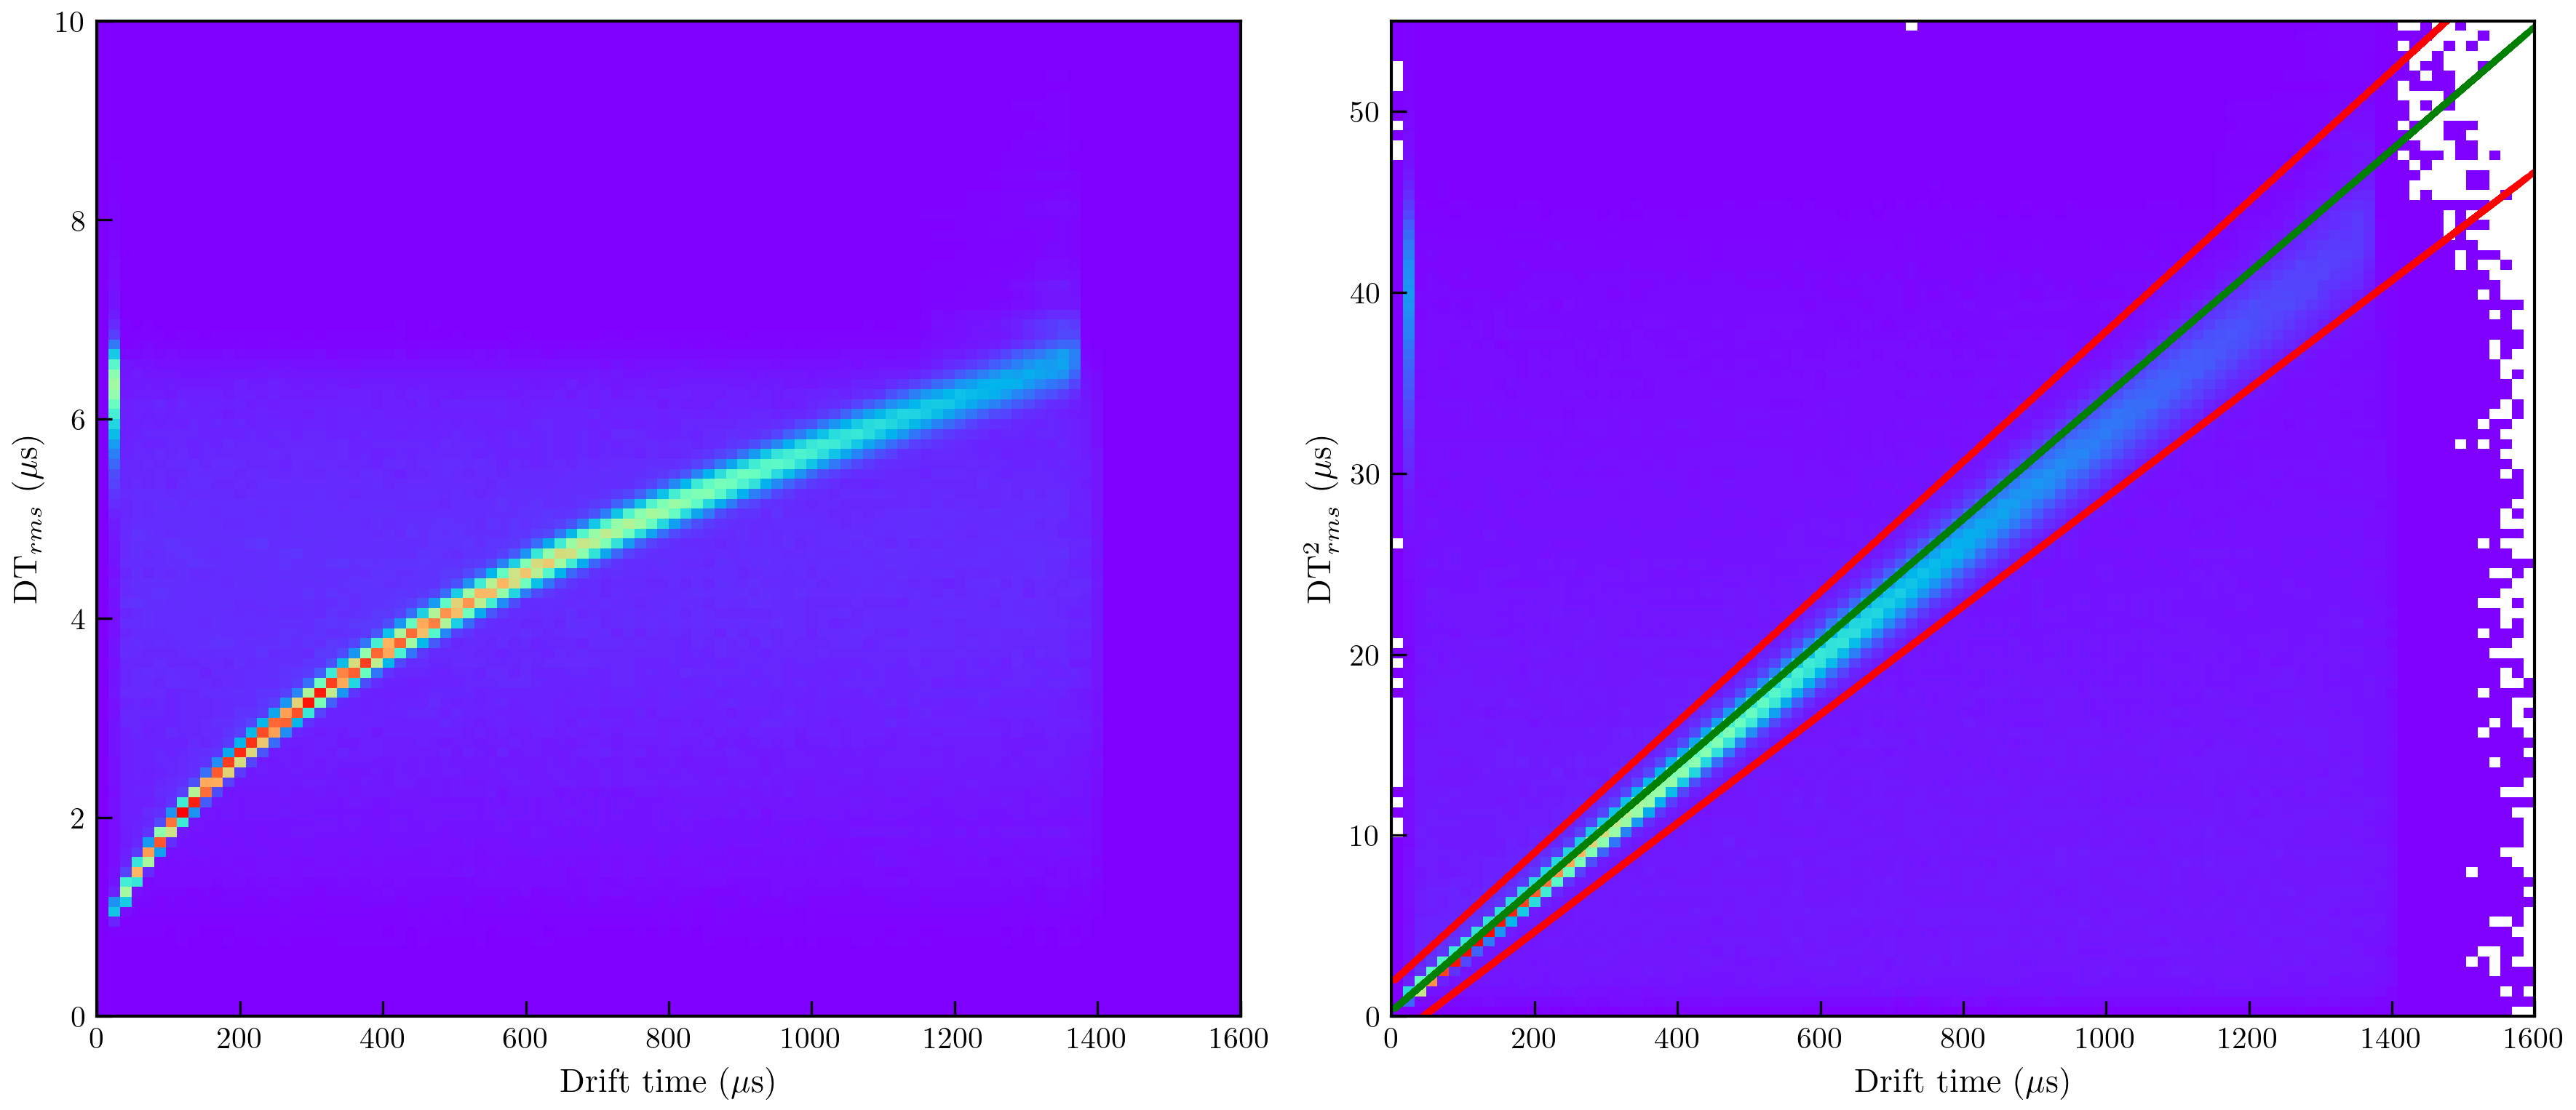

In [23]:
#krn100.monitor_S1S2(kdst)
#krn100.monitor_S2(kdst)
krn100.monitor_S2s_dtime(kdst)
#krn100.monitor_lifetime(kdst)

## Standard selection

In [24]:
kdst_, effs    = krn100.kdst_select(kdst)

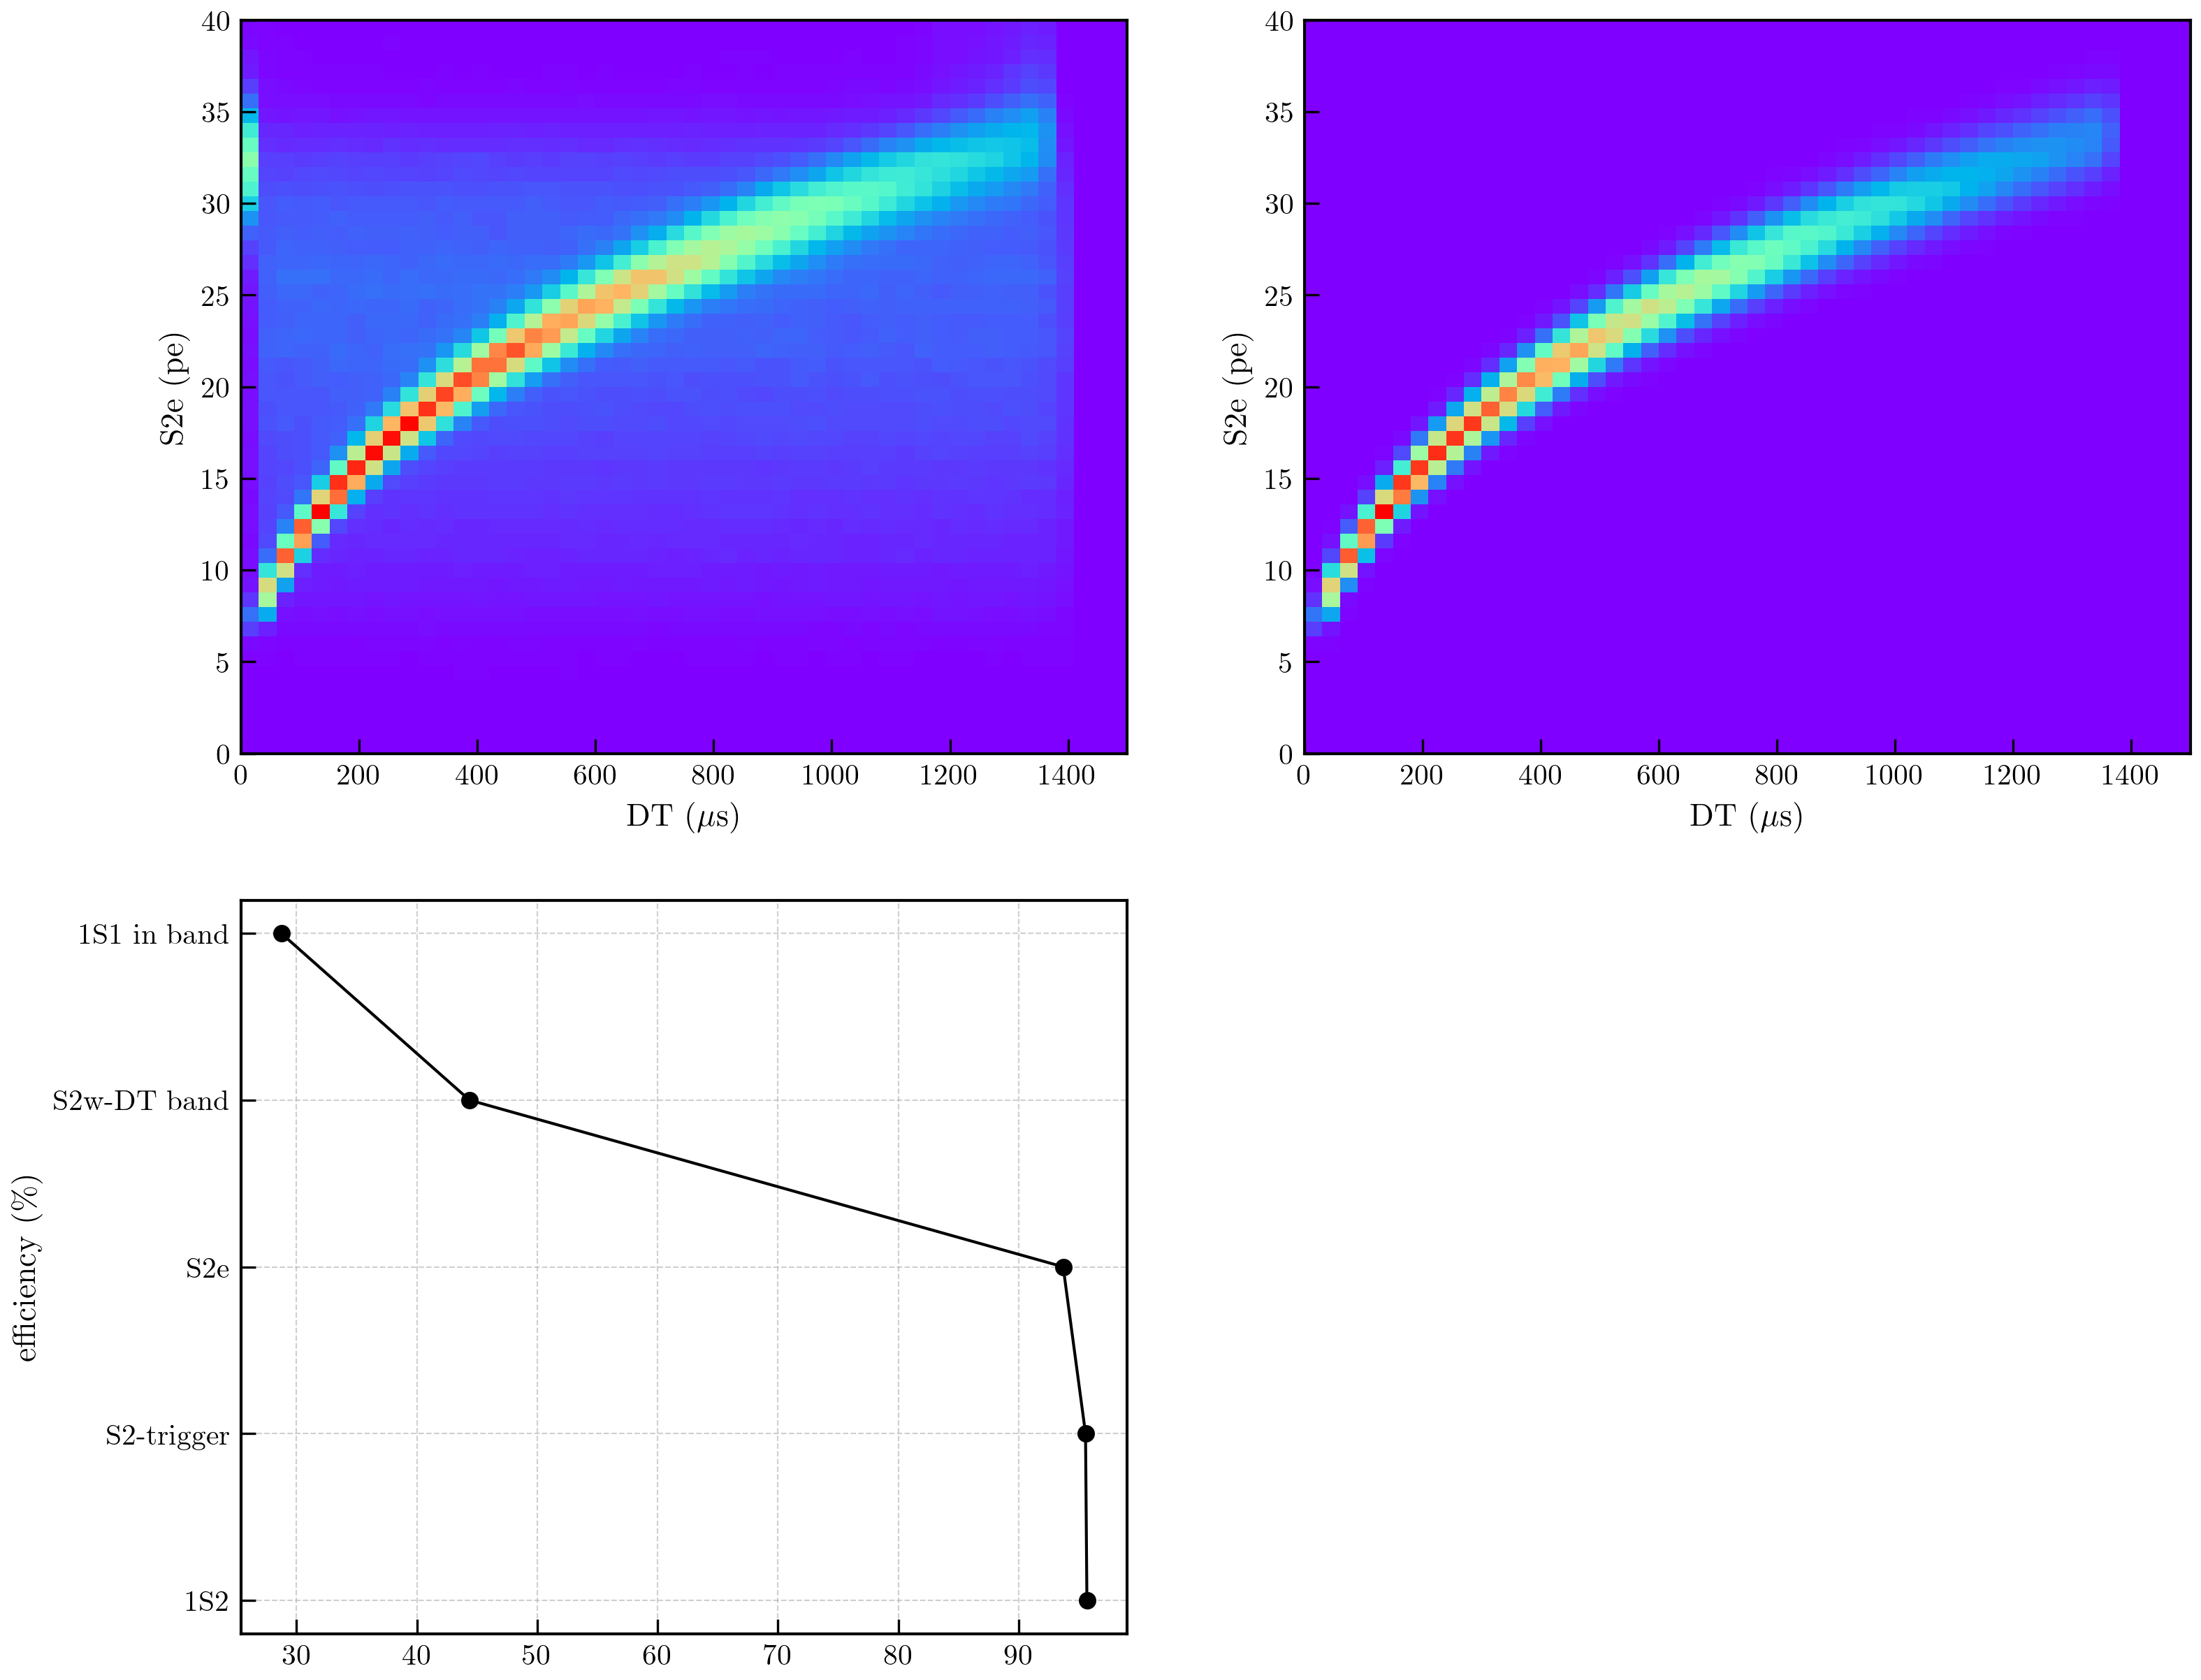

In [25]:
cv = pltext.canvas(4, 2)
cv(3);
names, vals = [x[0] for x in effs], [100.*x[1] for x in effs]
plt.plot(vals, names, marker = "o", color = 'black', lw =1); plt.ylabel("efficiency (\%)")
cv(1); plt.hist2d(kdst.DT, kdst.S2w, 50, ((0, 1500), (0, 40))); 
plt.xlabel(r'DT ($\mu$s)'), plt.ylabel('S2e (pe)');
cv(2); plt.hist2d(kdst_.DT, kdst_.S2w, 50, ((0, 1500), (0, 40))); 
plt.xlabel(r'DT ($\mu$s)'), plt.ylabel('S2e (pe)');

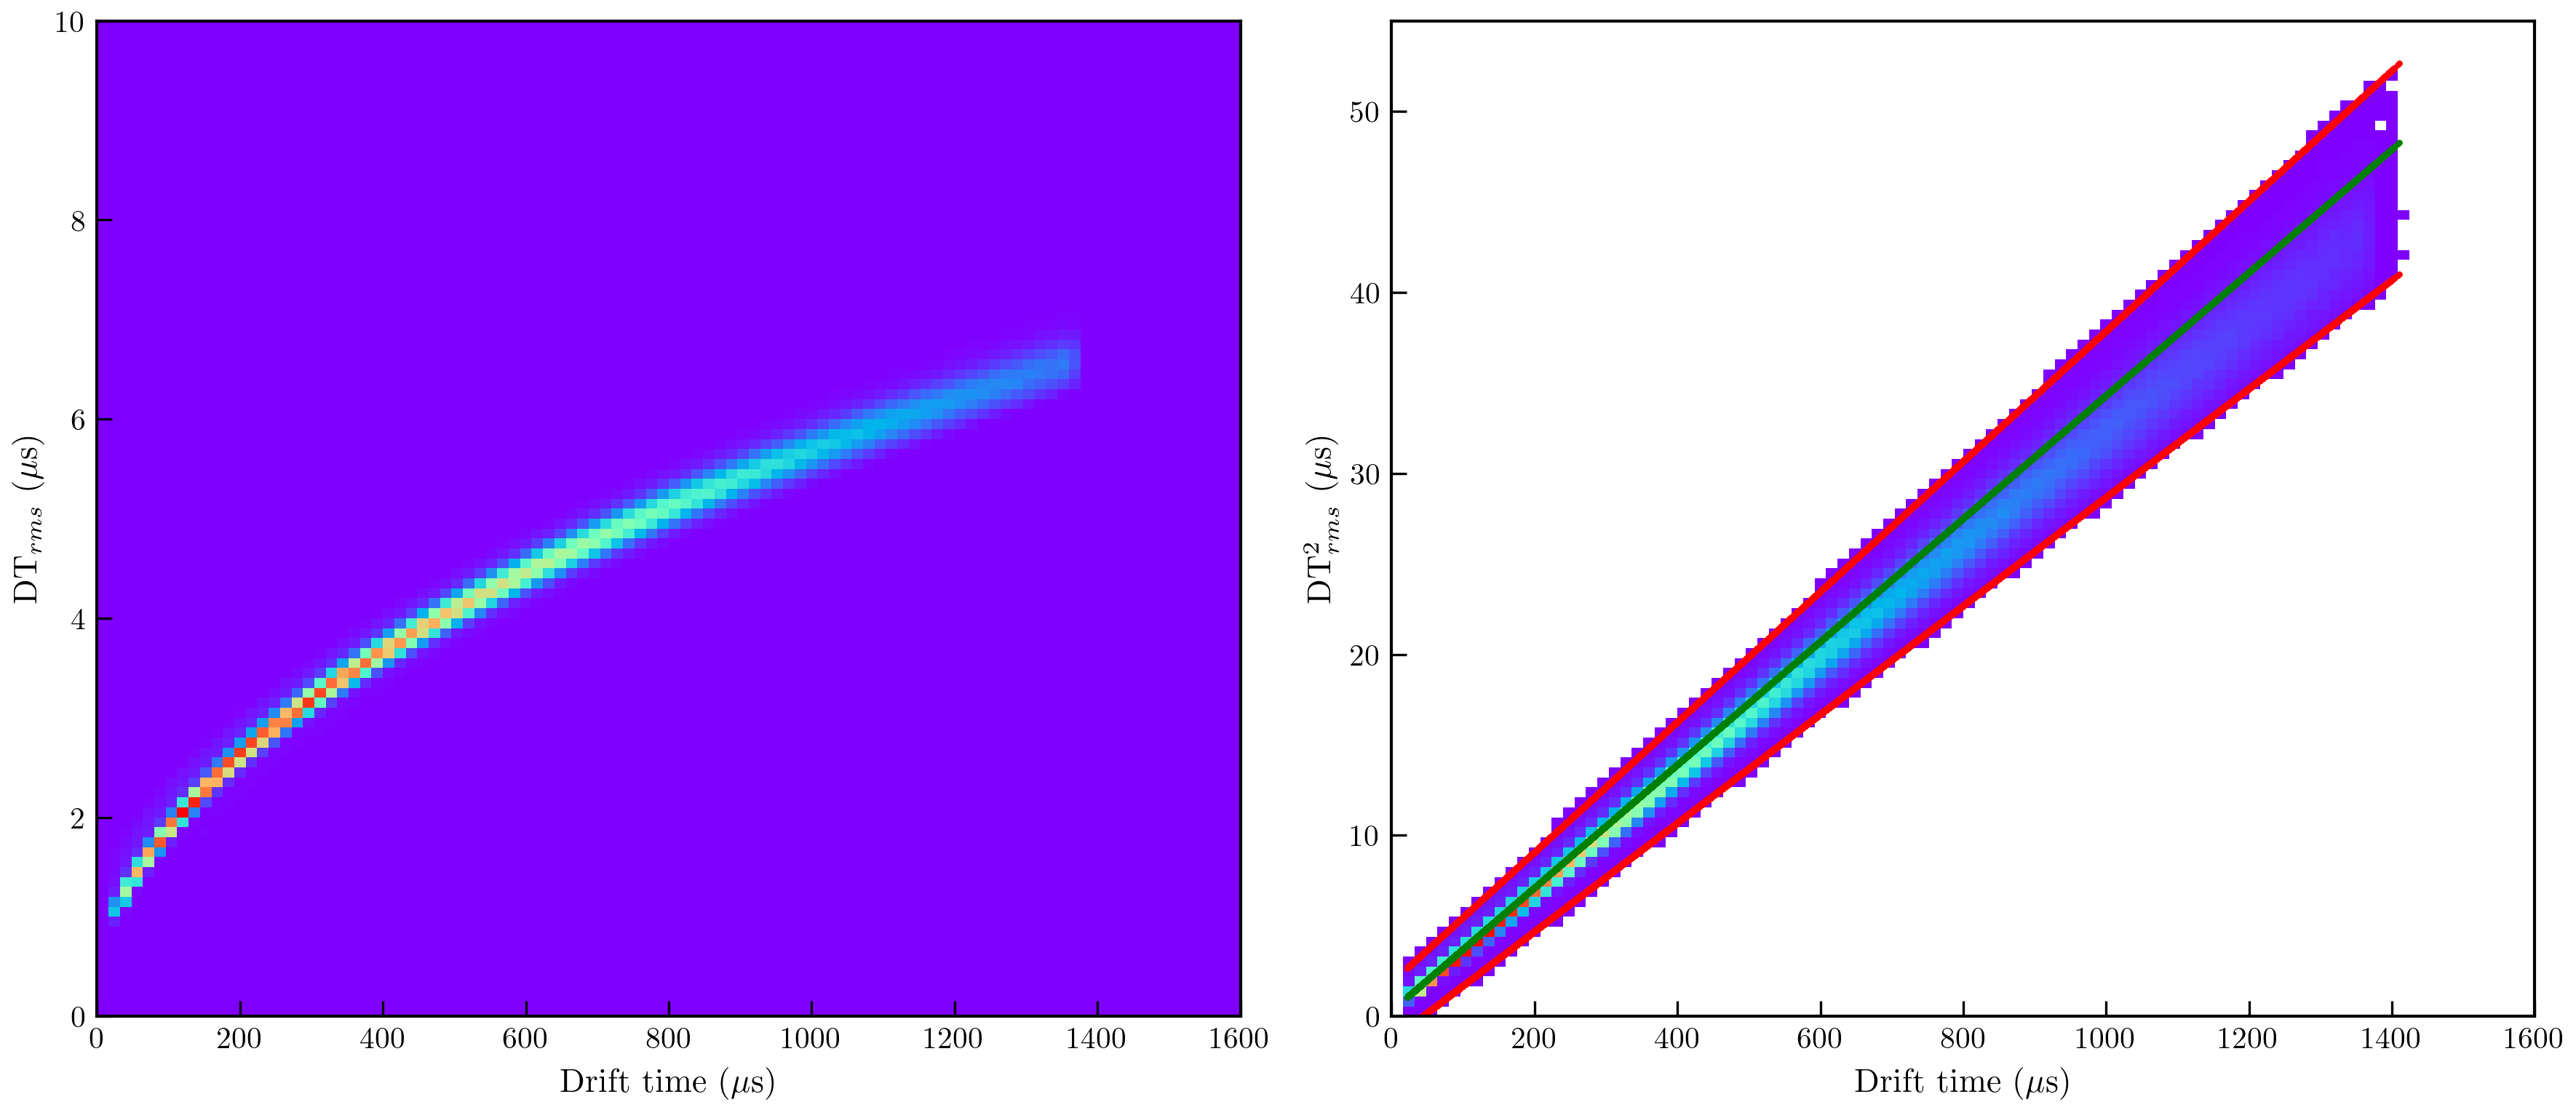

In [26]:
#krn100.monitor_S1S2(kdst_)
#krn100.monitor_S2(kdst_)
krn100.monitor_S2s_dtime(kdst_)
#krn100.monitor_lifetime(kdst_)

## Fidutal selection

In [80]:
df = kdst_
sels = {}
sels['R']        = ut.in_range(df.R  , (0., 500.))
sels['DT']       = ut.in_range(df.DT , (0., 2000.))
sels['S2e']      = ut.in_range(df.S2e, (0e3, 9e3))
sels['fidutial'] = (sels['R']) & (sels['DT']) & (sels['S2e'])

## Clean data : fidutial and residuals

In [110]:
counts_min = 40
pitch      = 15.00
xmin       = -489.825
#xbins      = np.arange(xmin-pitch, -xmin + pitch, pitch)
xbins      = np.arange(xmin, -xmin + pitch, pitch)
bins       = (xbins, xbins) 
print('number of bins ', len(xbins), ', range : ', xbins[0], ', ', xbins[-1])

number of bins  67 , range :  -489.825 ,  500.175


In [111]:
#df     = kdst_
sel    = sels['fidutial']
coors  = df[sel].X, df[sel].Y
energy = df[sel].S2e
dtime  = df[sel].DT

In [112]:
min_sigma = 0.9
dt0       = 0 # compute the map in the EL
sel       = sels['fidutial']
krf, res_1, usel = krtool.krmap_clean((df[sel].X, df[sel].Y), df.DT[sel], df[sel].S2e,
                                       bins = bins, dt0 = dt0, plot = False)

sigma 0.89 done  False  eff 99.63
sigma 0.99 done  True  eff 100.00


In [113]:
cdf = df[sel][usel]

## Compare LT map, LT Unique, 3D

In [129]:
krf, res_1 = krtool.krmap((cdf.X, cdf.Y), cdf.DT, cdf.S2e, bins = bins)
cene_1     = krtool.krmap_scale((cdf.X, cdf.Y), cdf.DT, cdf.S2e, krf, scale = 41.5)

In [130]:
k2d, res_2 = krtool.krmap_ltunique((cdf.X, cdf.Y), cdf.DT, cdf.S2e, bins = bins, rmax = 350., boost = False)
cene_2     = krtool.krmap_ltunique_scale((cdf.X, cdf.Y), cdf.DT, cdf.S2e, k2d, scale = 41.5)

In [131]:
k3d, res_3 = prof.profile((cdf.X, cdf.Y, cdf.DT), cdf.S2e, bins = (68, 68, 10)) 
cene_3     = prof.profile_scale((cdf.X, cdf.Y, cdf.DT), cdf.S2e, k3d, 41.5)

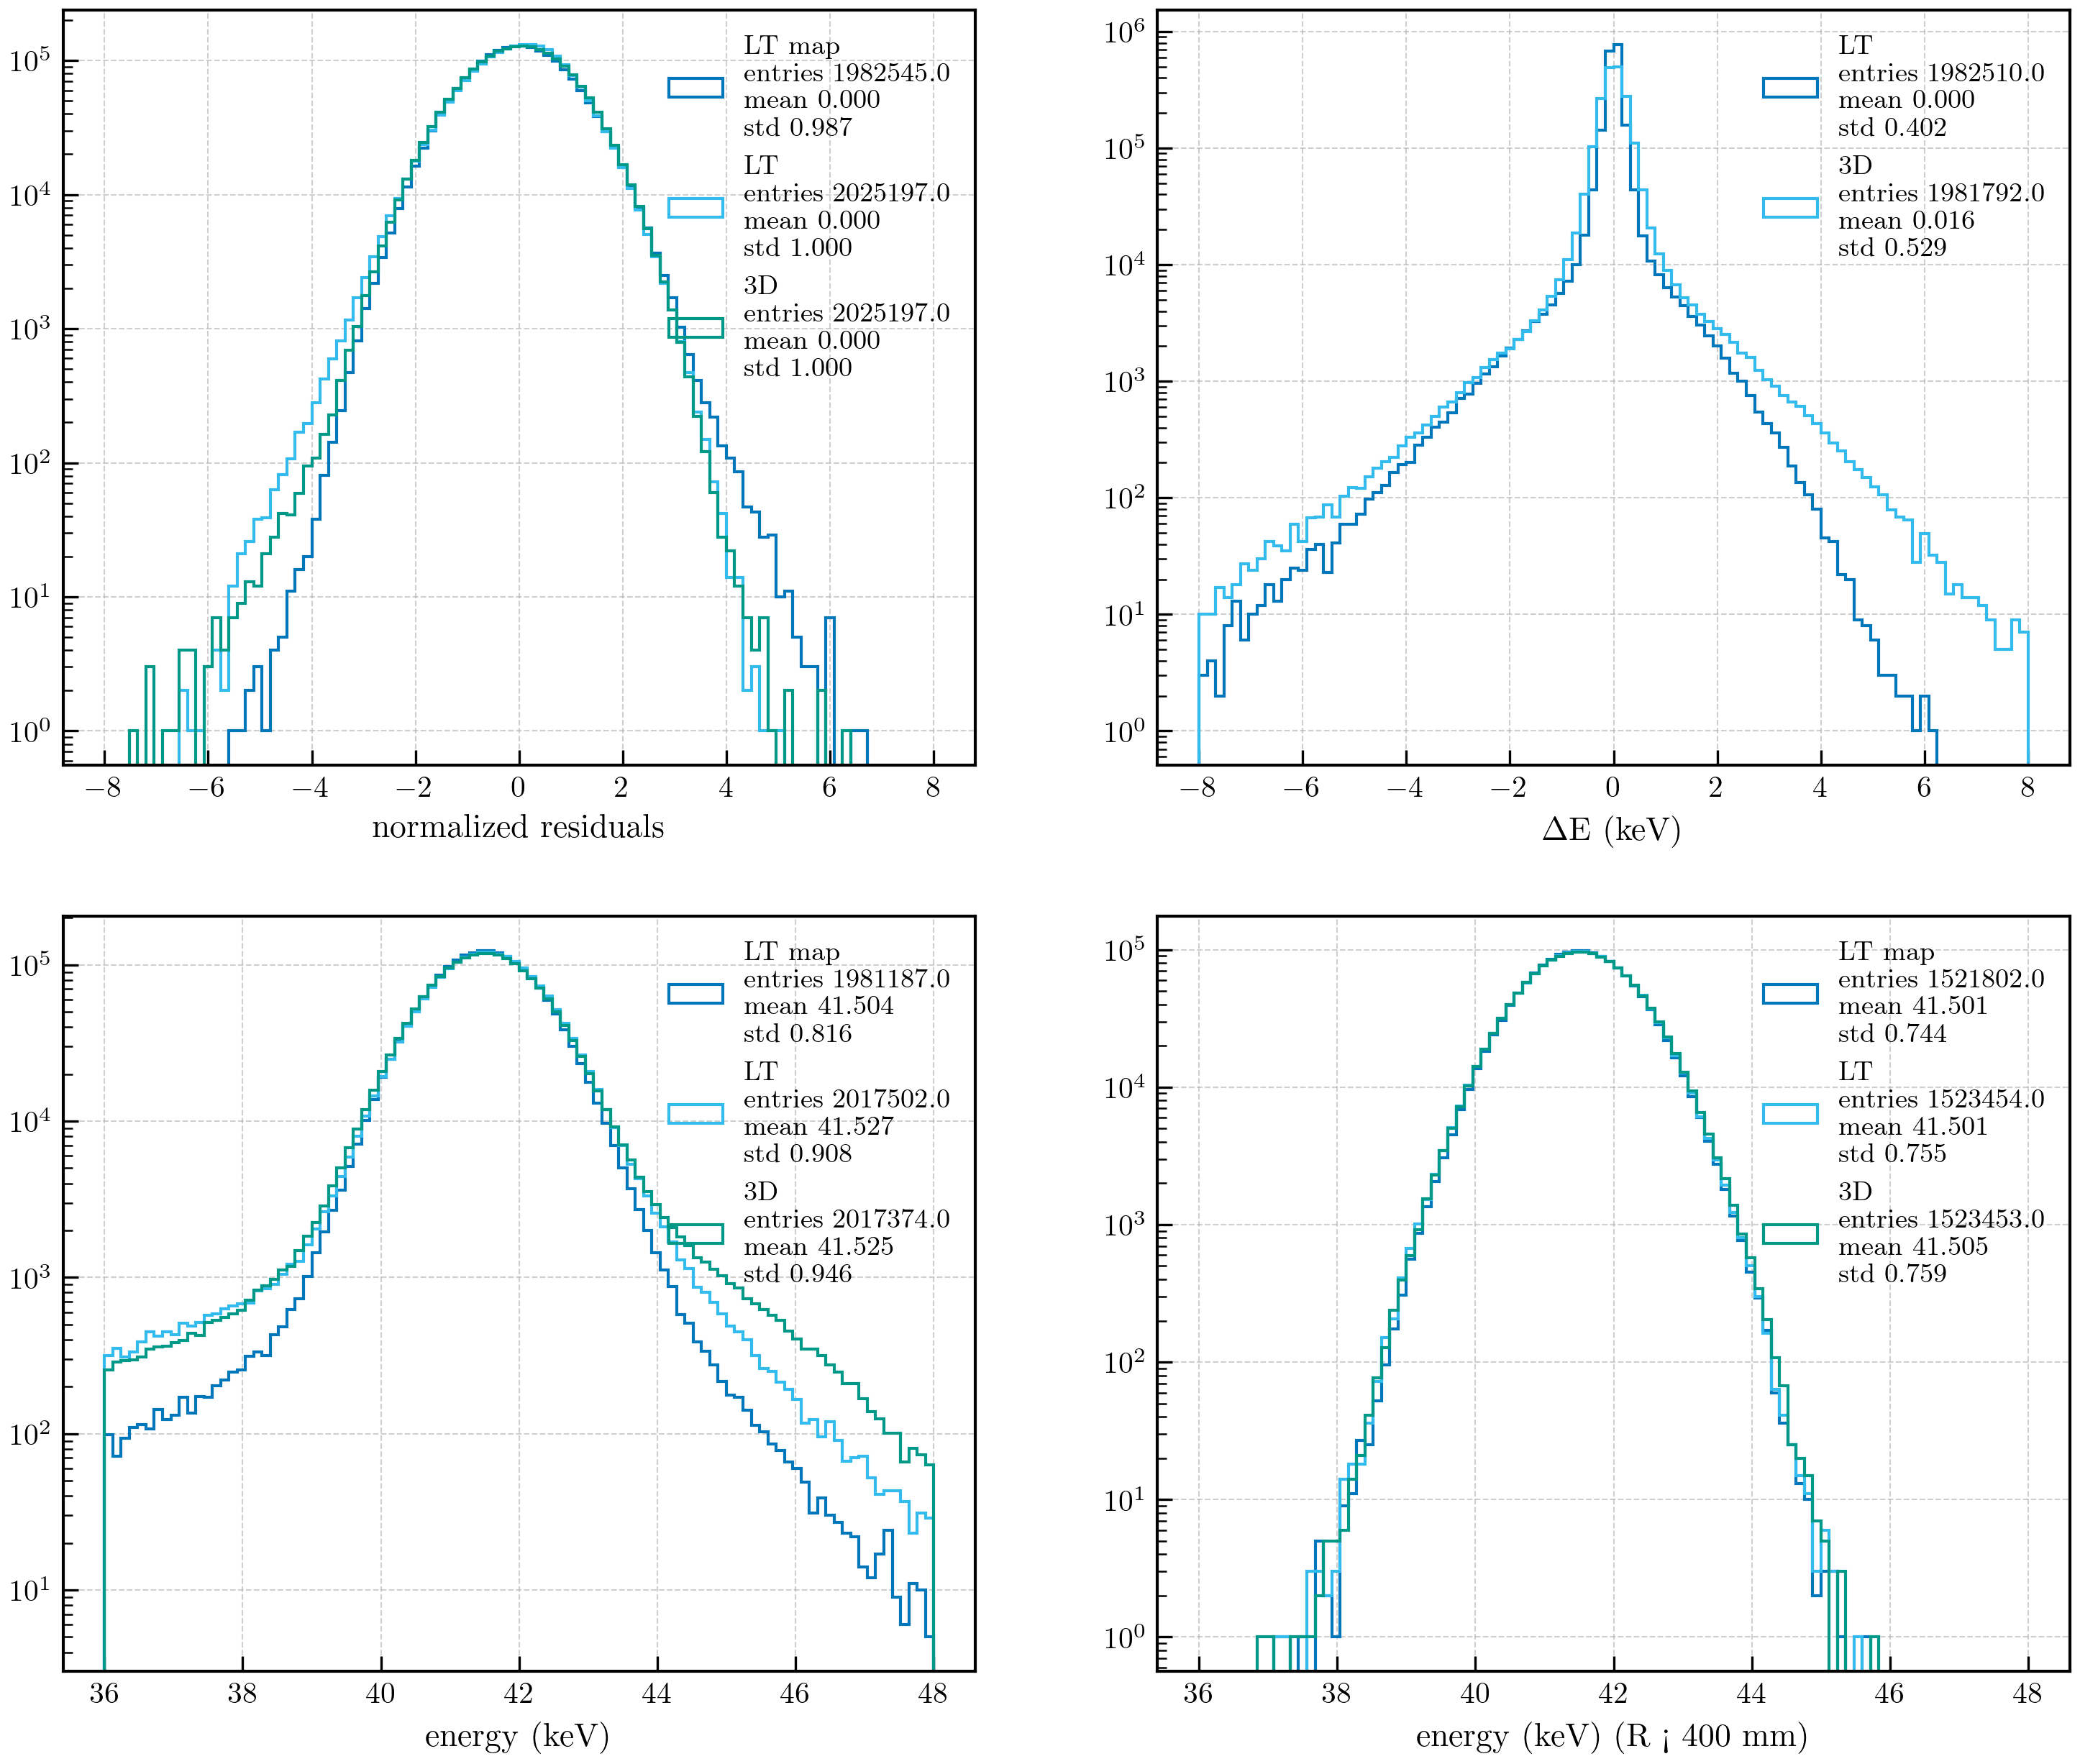

In [133]:
rsel = cdf.R < 400.
cv = pltext.canvas(4, 2)
cv(1);
pltext.hist(res_1, 100, (-8, 8), label = 'LT map'); 
pltext.hist(res_2, 100, (-8, 8), label = 'LT');
pltext.hist(res_3, 100, (-8, 8), label = '3D'); 
plt.yscale('log'); plt.xlabel("normalized residuals"); plt.legend();
cv(2);
pltext.hist(cene_2 - cene_1, 100, (-8, 8), label = r'LT');
pltext.hist(cene_3 - cene_1, 100, (-8, 8), label = r'3D');
plt.yscale('log'); plt.xlabel(r"$\Delta$E (keV)");
cv(3);
pltext.hist(cene_1, 100, (36, 48), label = 'LT map');
pltext.hist(cene_2, 100, (36, 48), label = 'LT'); 
pltext.hist(cene_3, 100, (36, 48), label = '3D');
plt.yscale('log'); plt.xlabel("energy (keV)"); plt.legend();
cv(4)
pltext.hist(cene_1[rsel], 100, (36, 48), label = 'LT map');
pltext.hist(cene_2[rsel], 100, (36, 48), label = 'LT'); 
pltext.hist(cene_3[rsel], 100, (36, 48), label = '3D'); 
plt.yscale('log'); plt.xlabel("energy (keV) (R < 400 mm)"); plt.legend();


## Compare mean corrected values with repect LT map (classic Kr map)

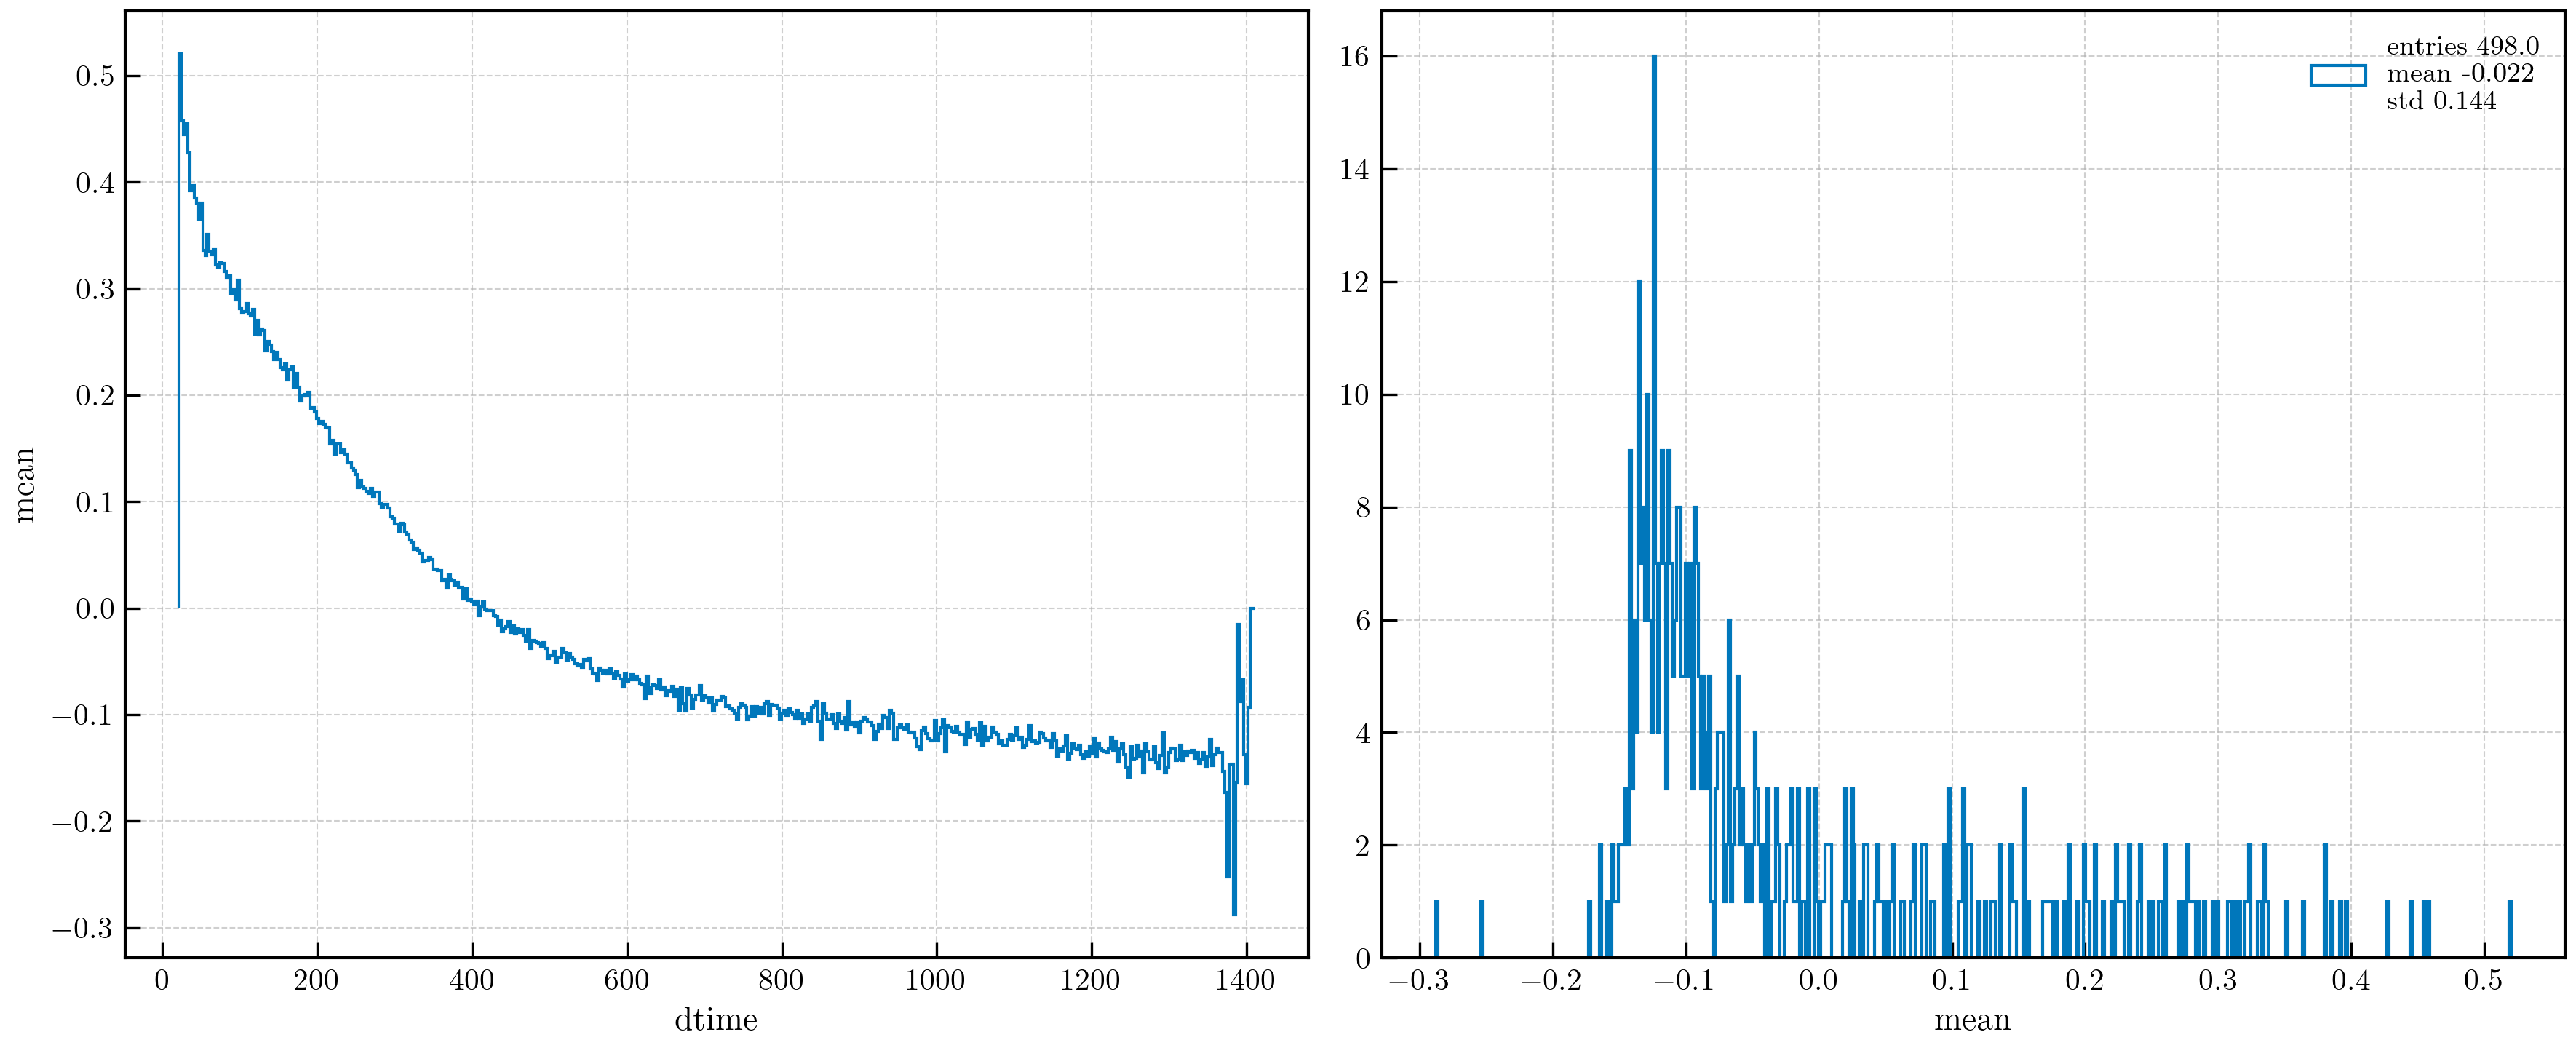

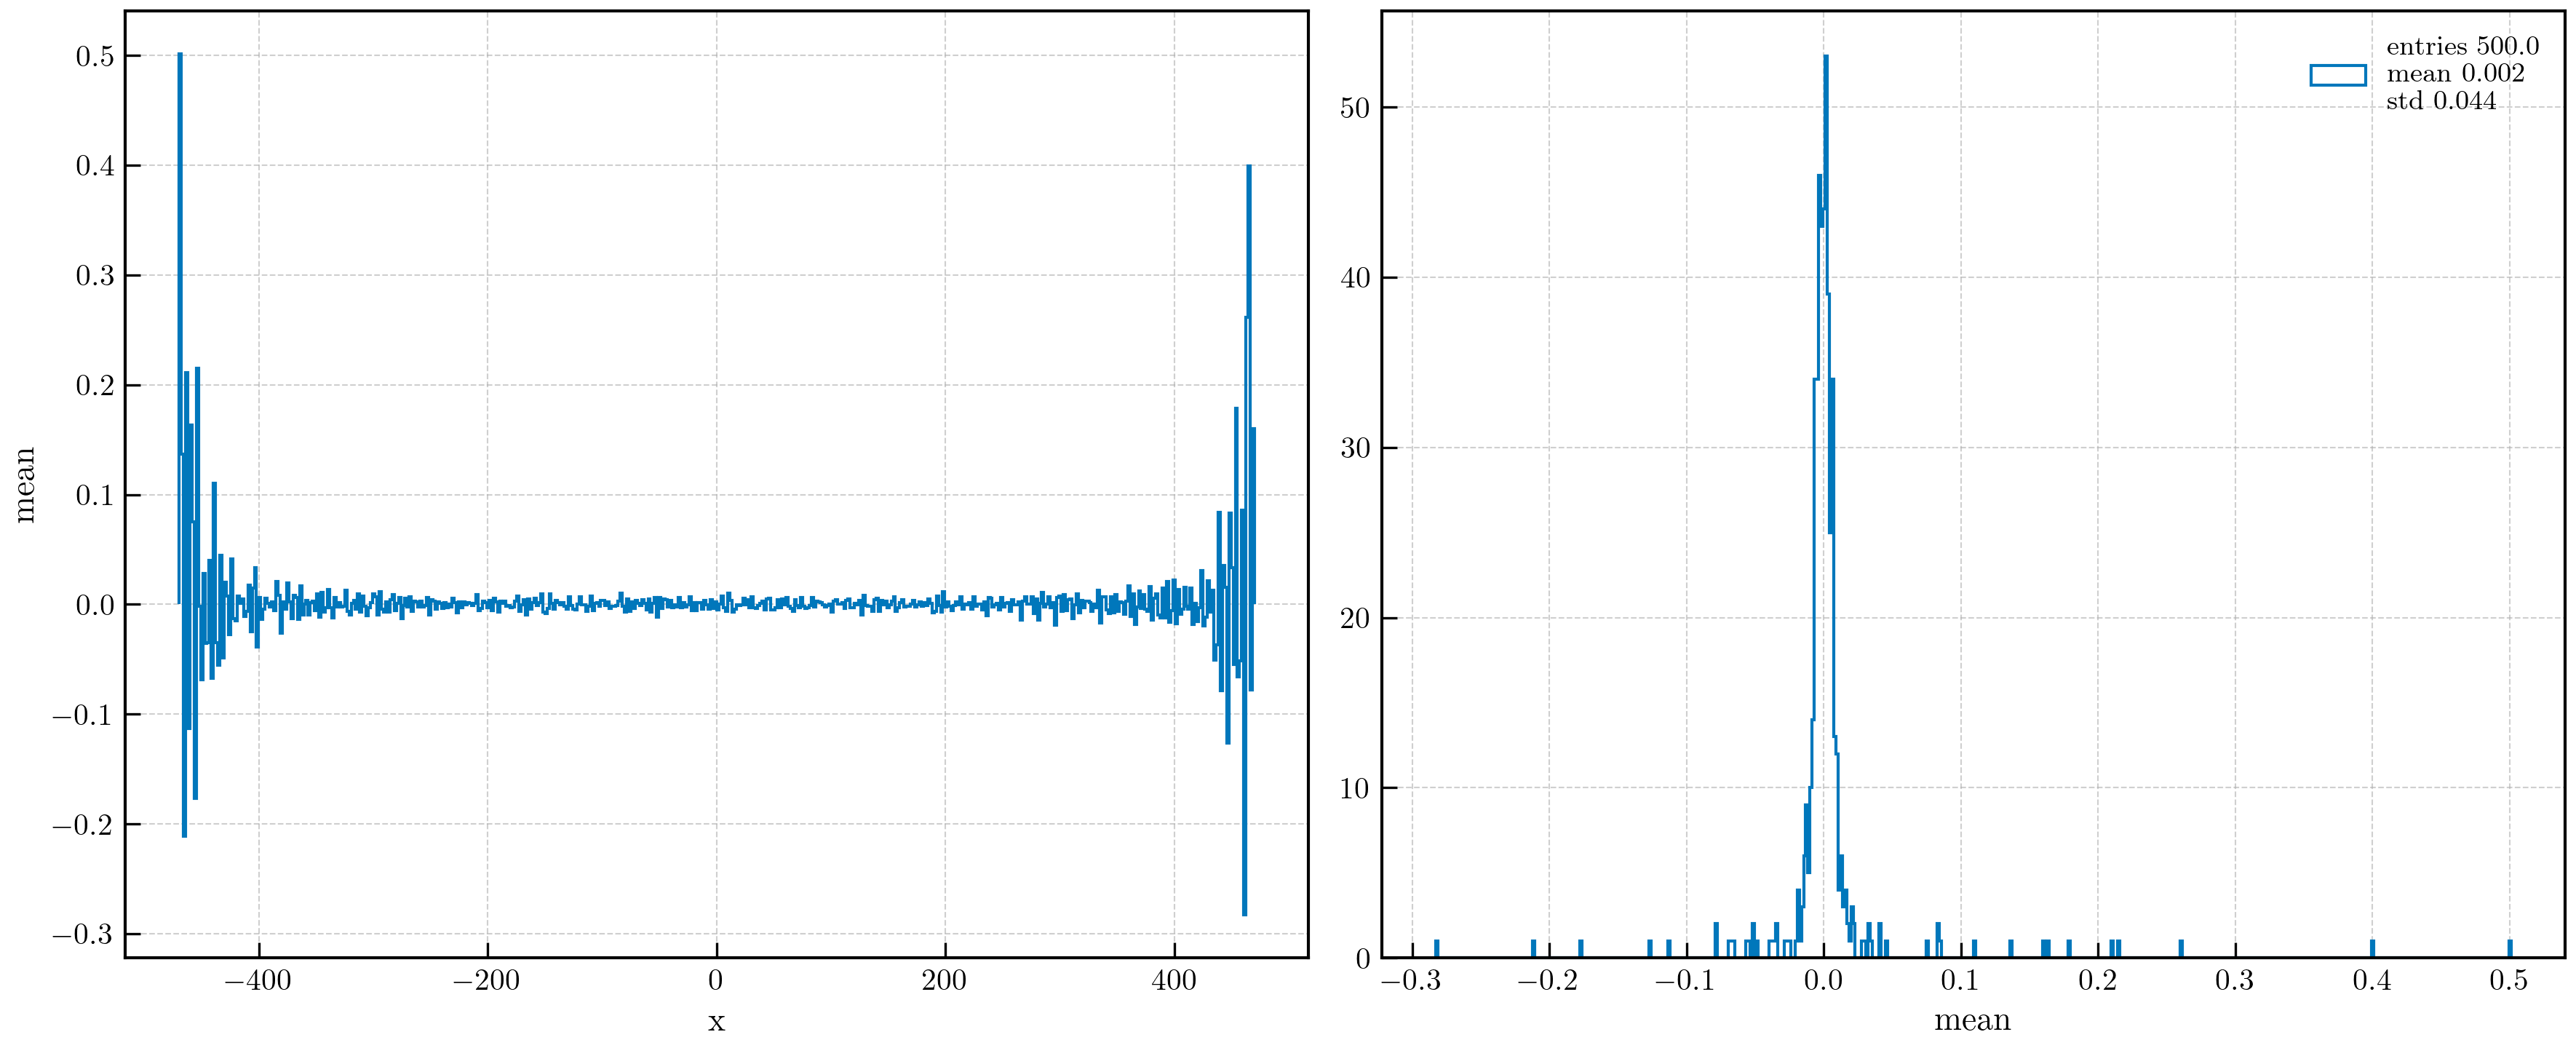

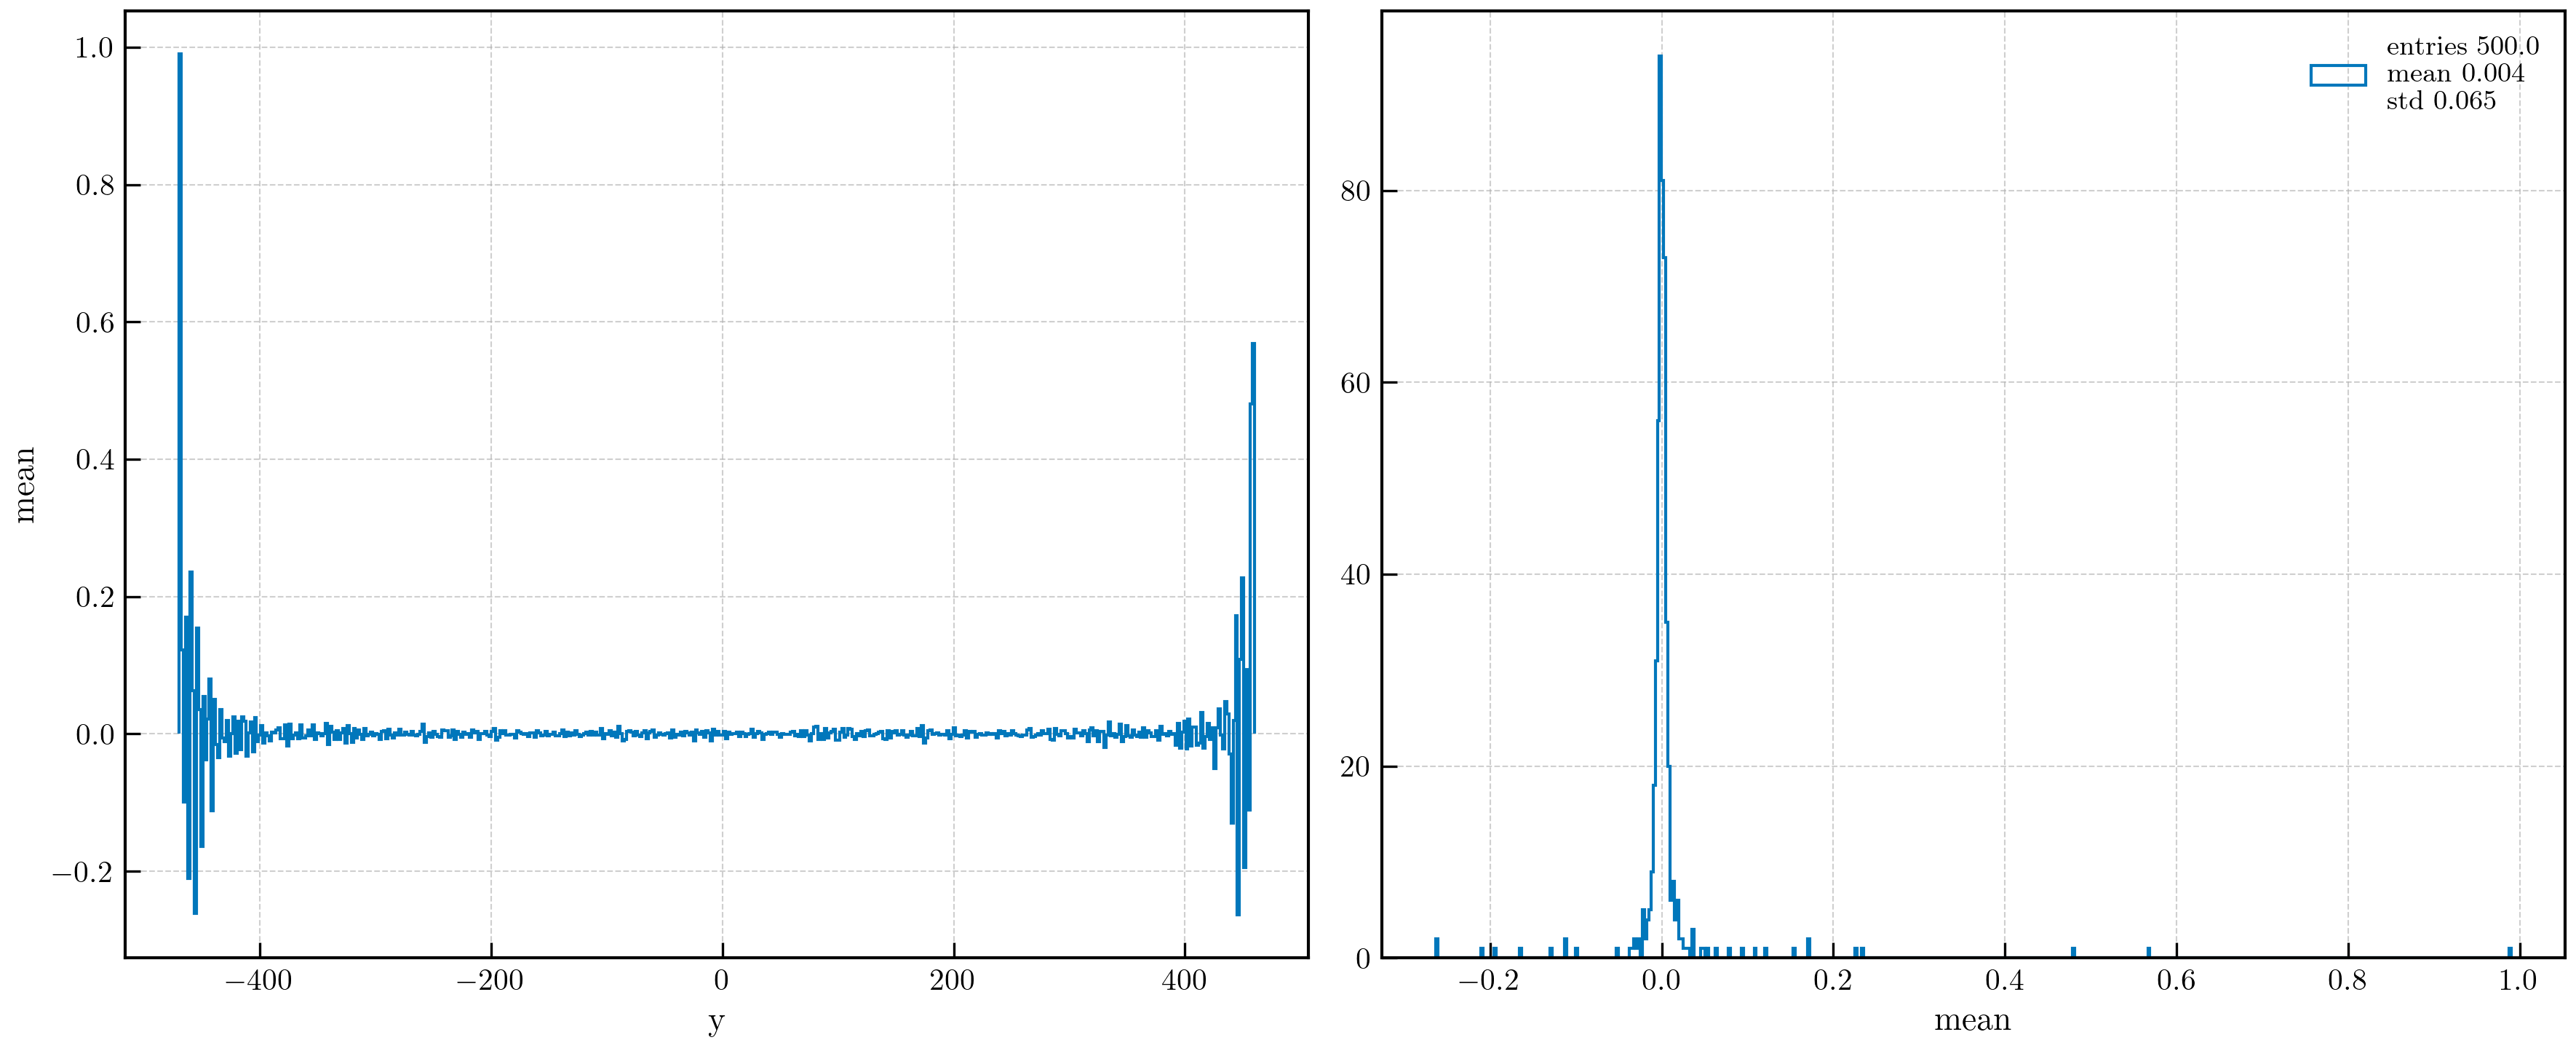

In [134]:
dene = cene_2 - cene_1
xsel = ~np.isnan(dene)
xdf = pd.DataFrame({'x' : cdf[xsel].X, 'y' : cdf[xsel].Y, 'dtime' : cdf[xsel].DT, 'energy': dene[xsel]})
krtool.plot_xydt_energy_profiles(xdf, nbins = 500)

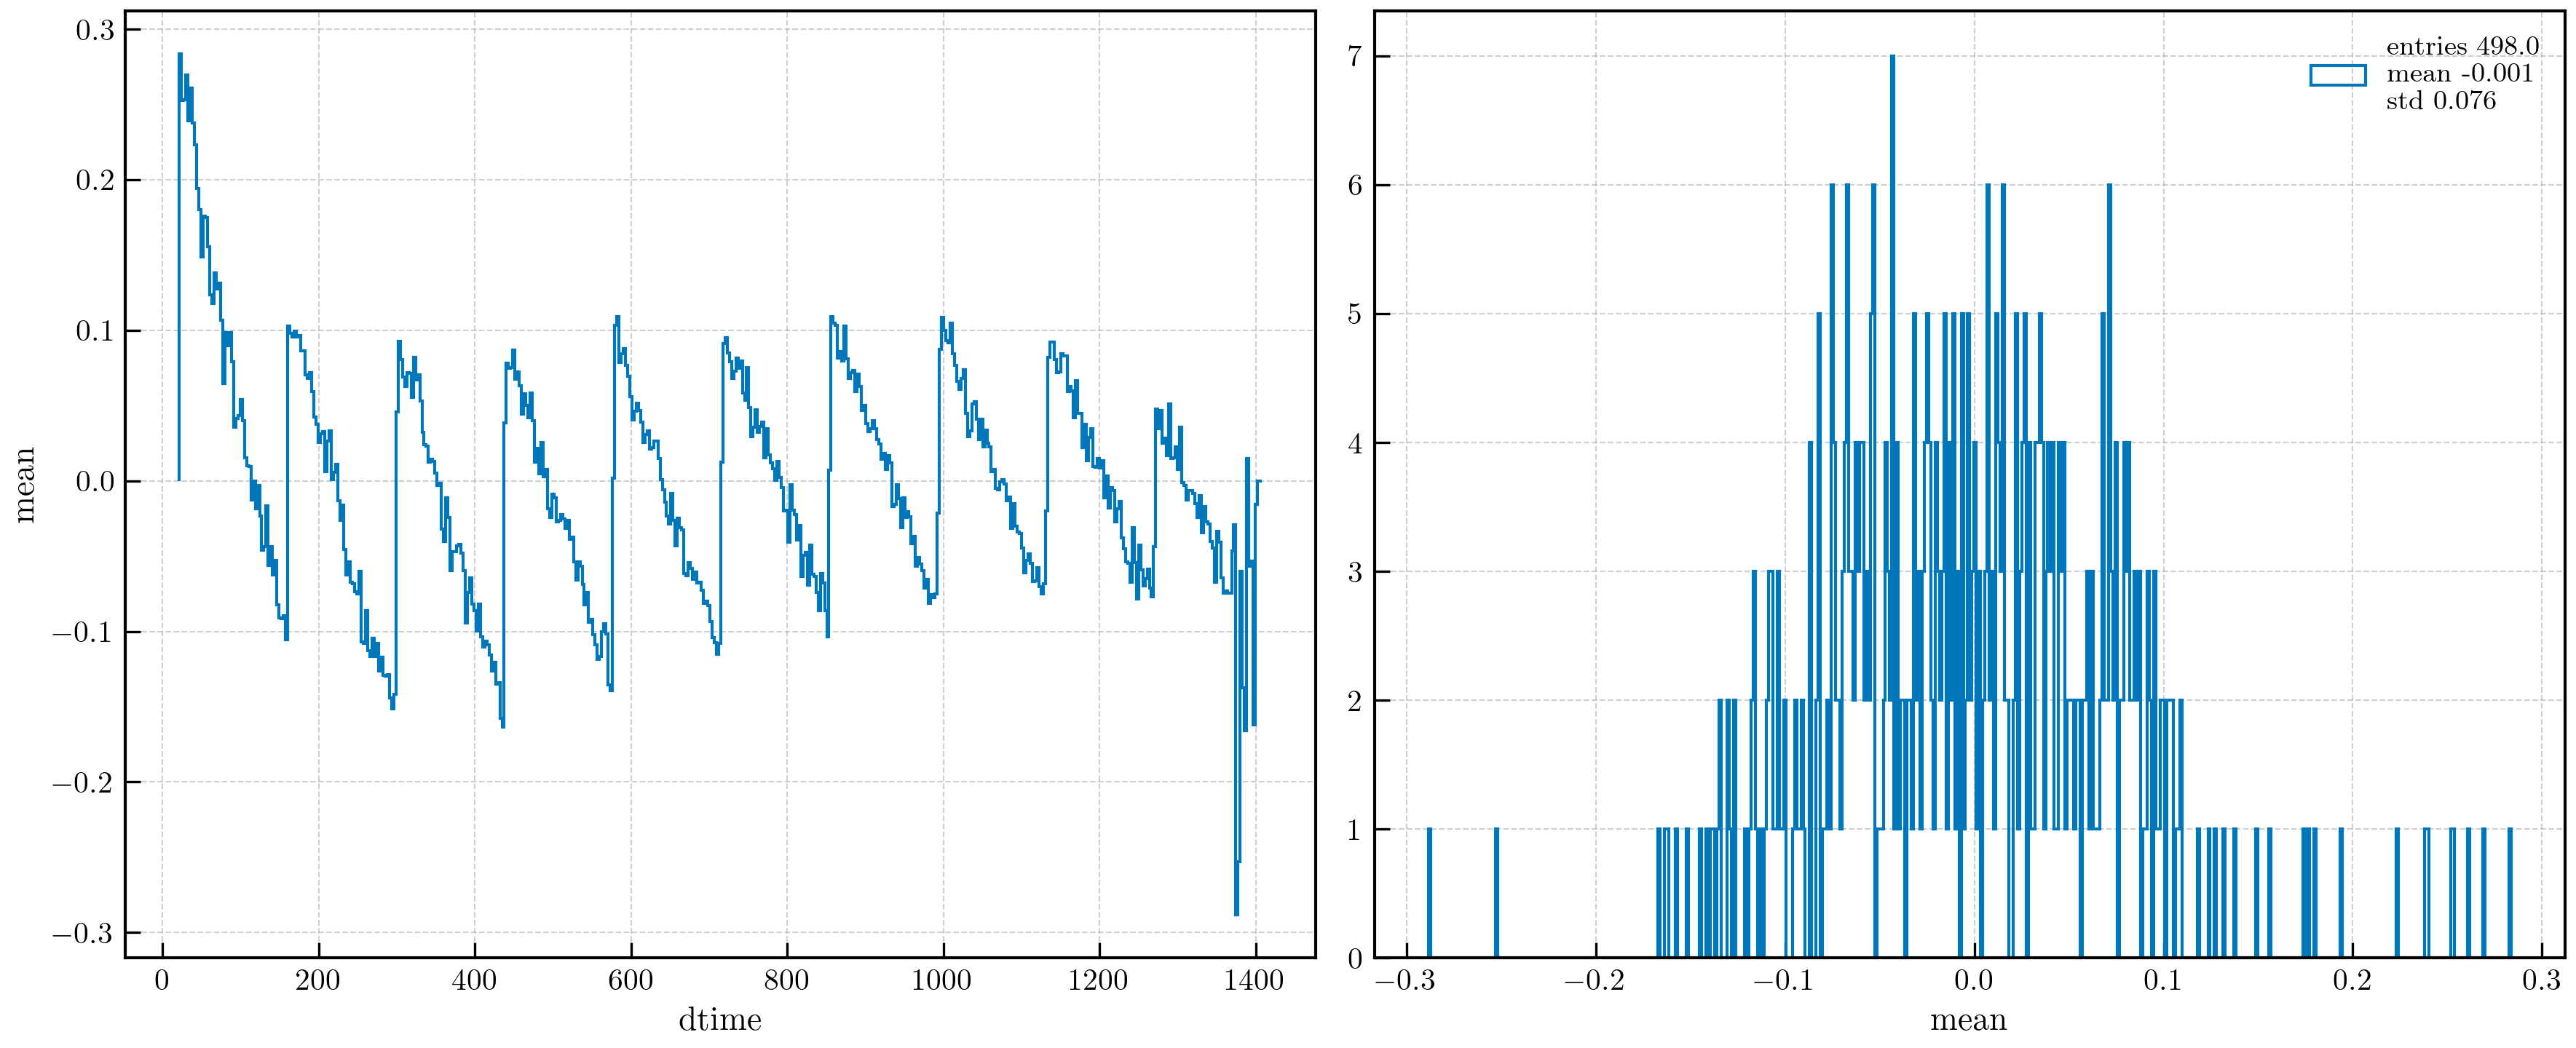

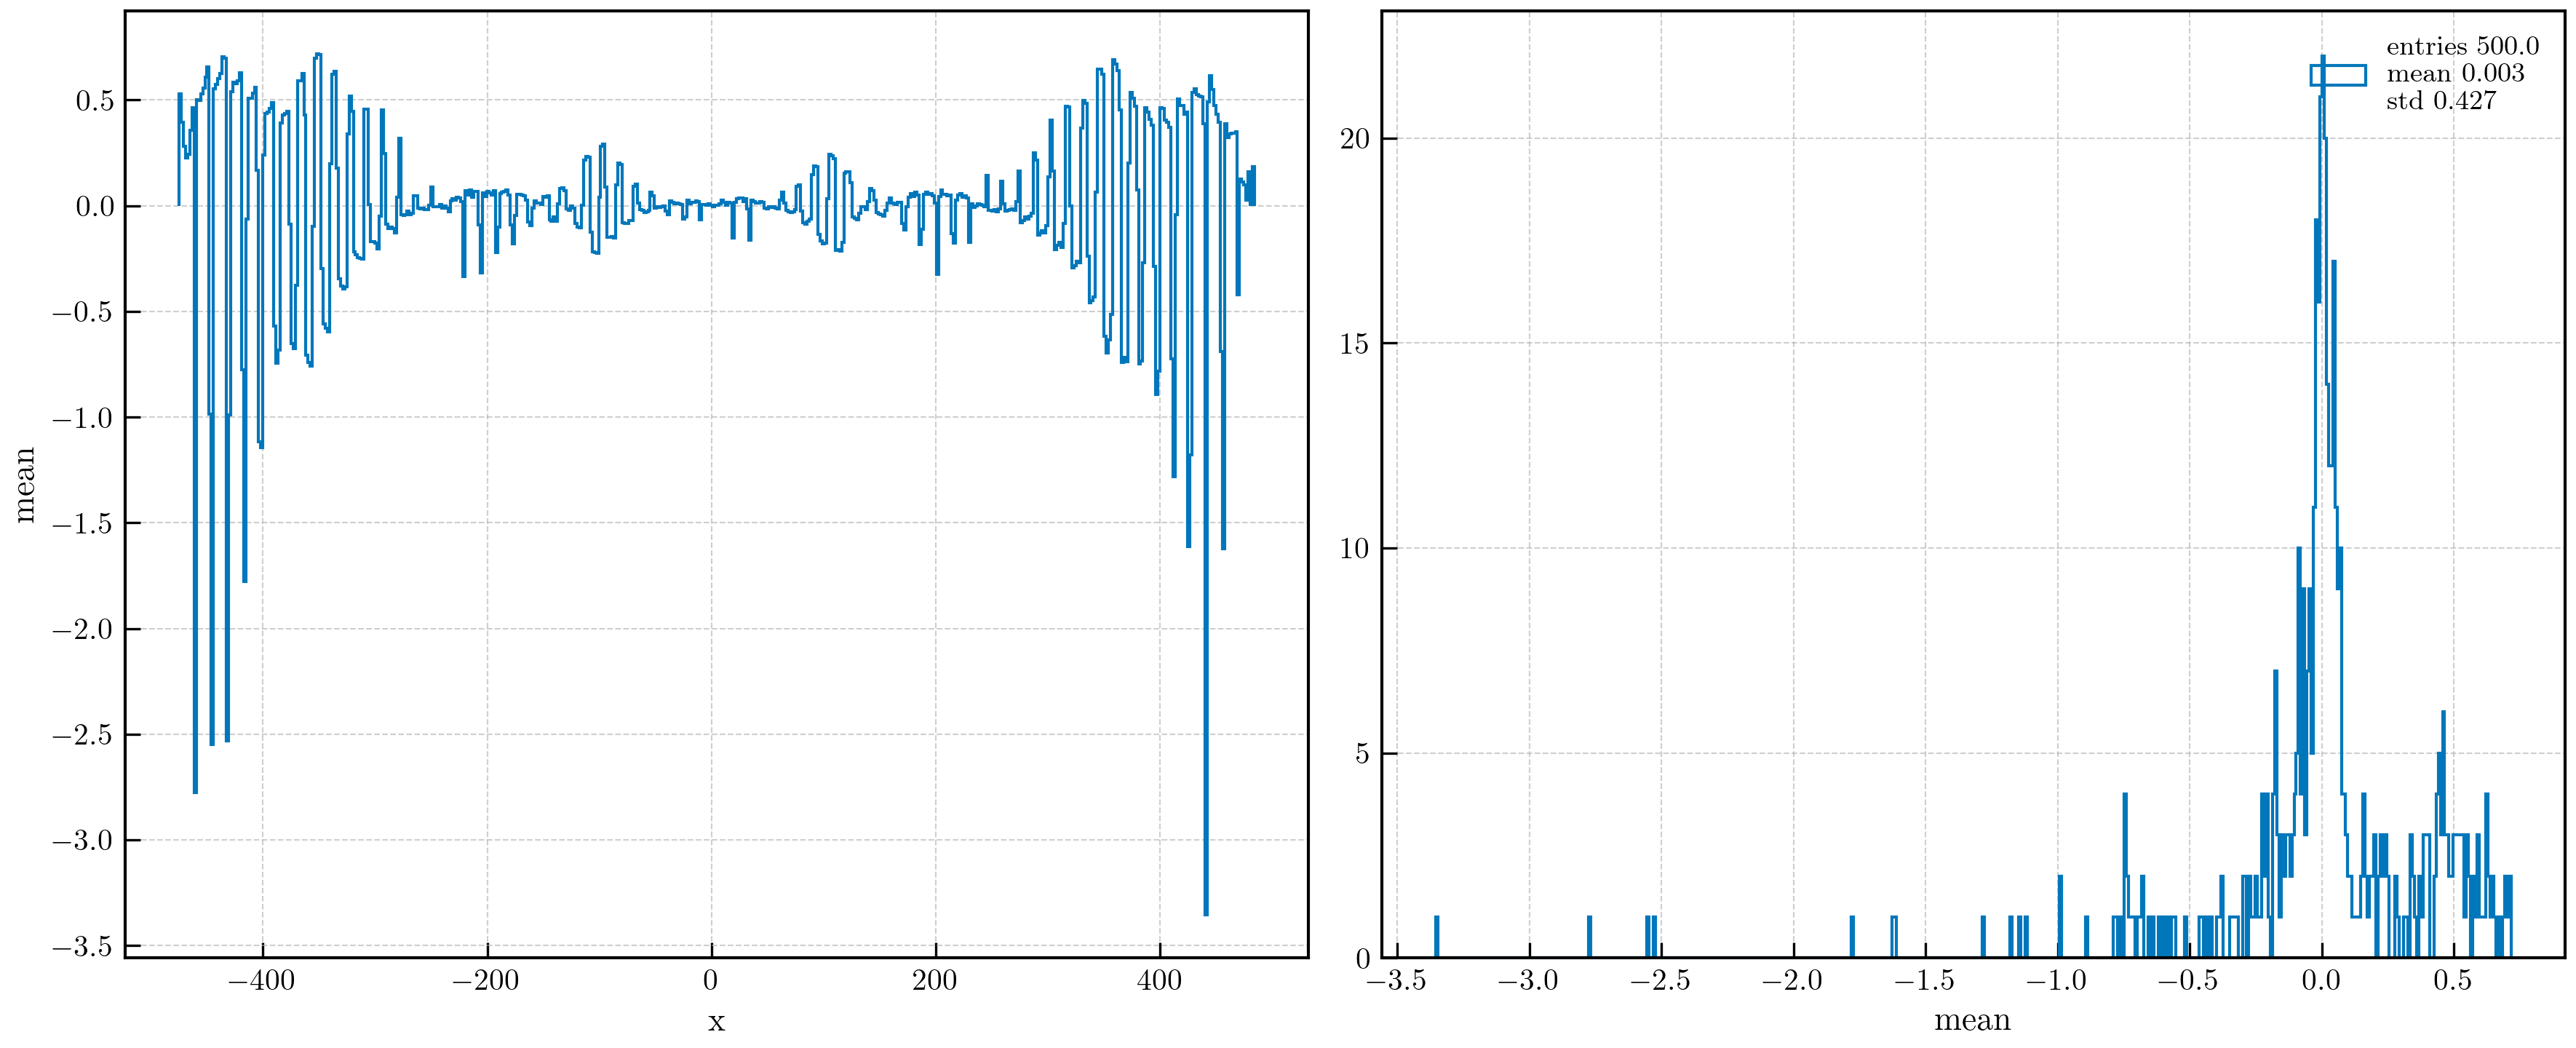

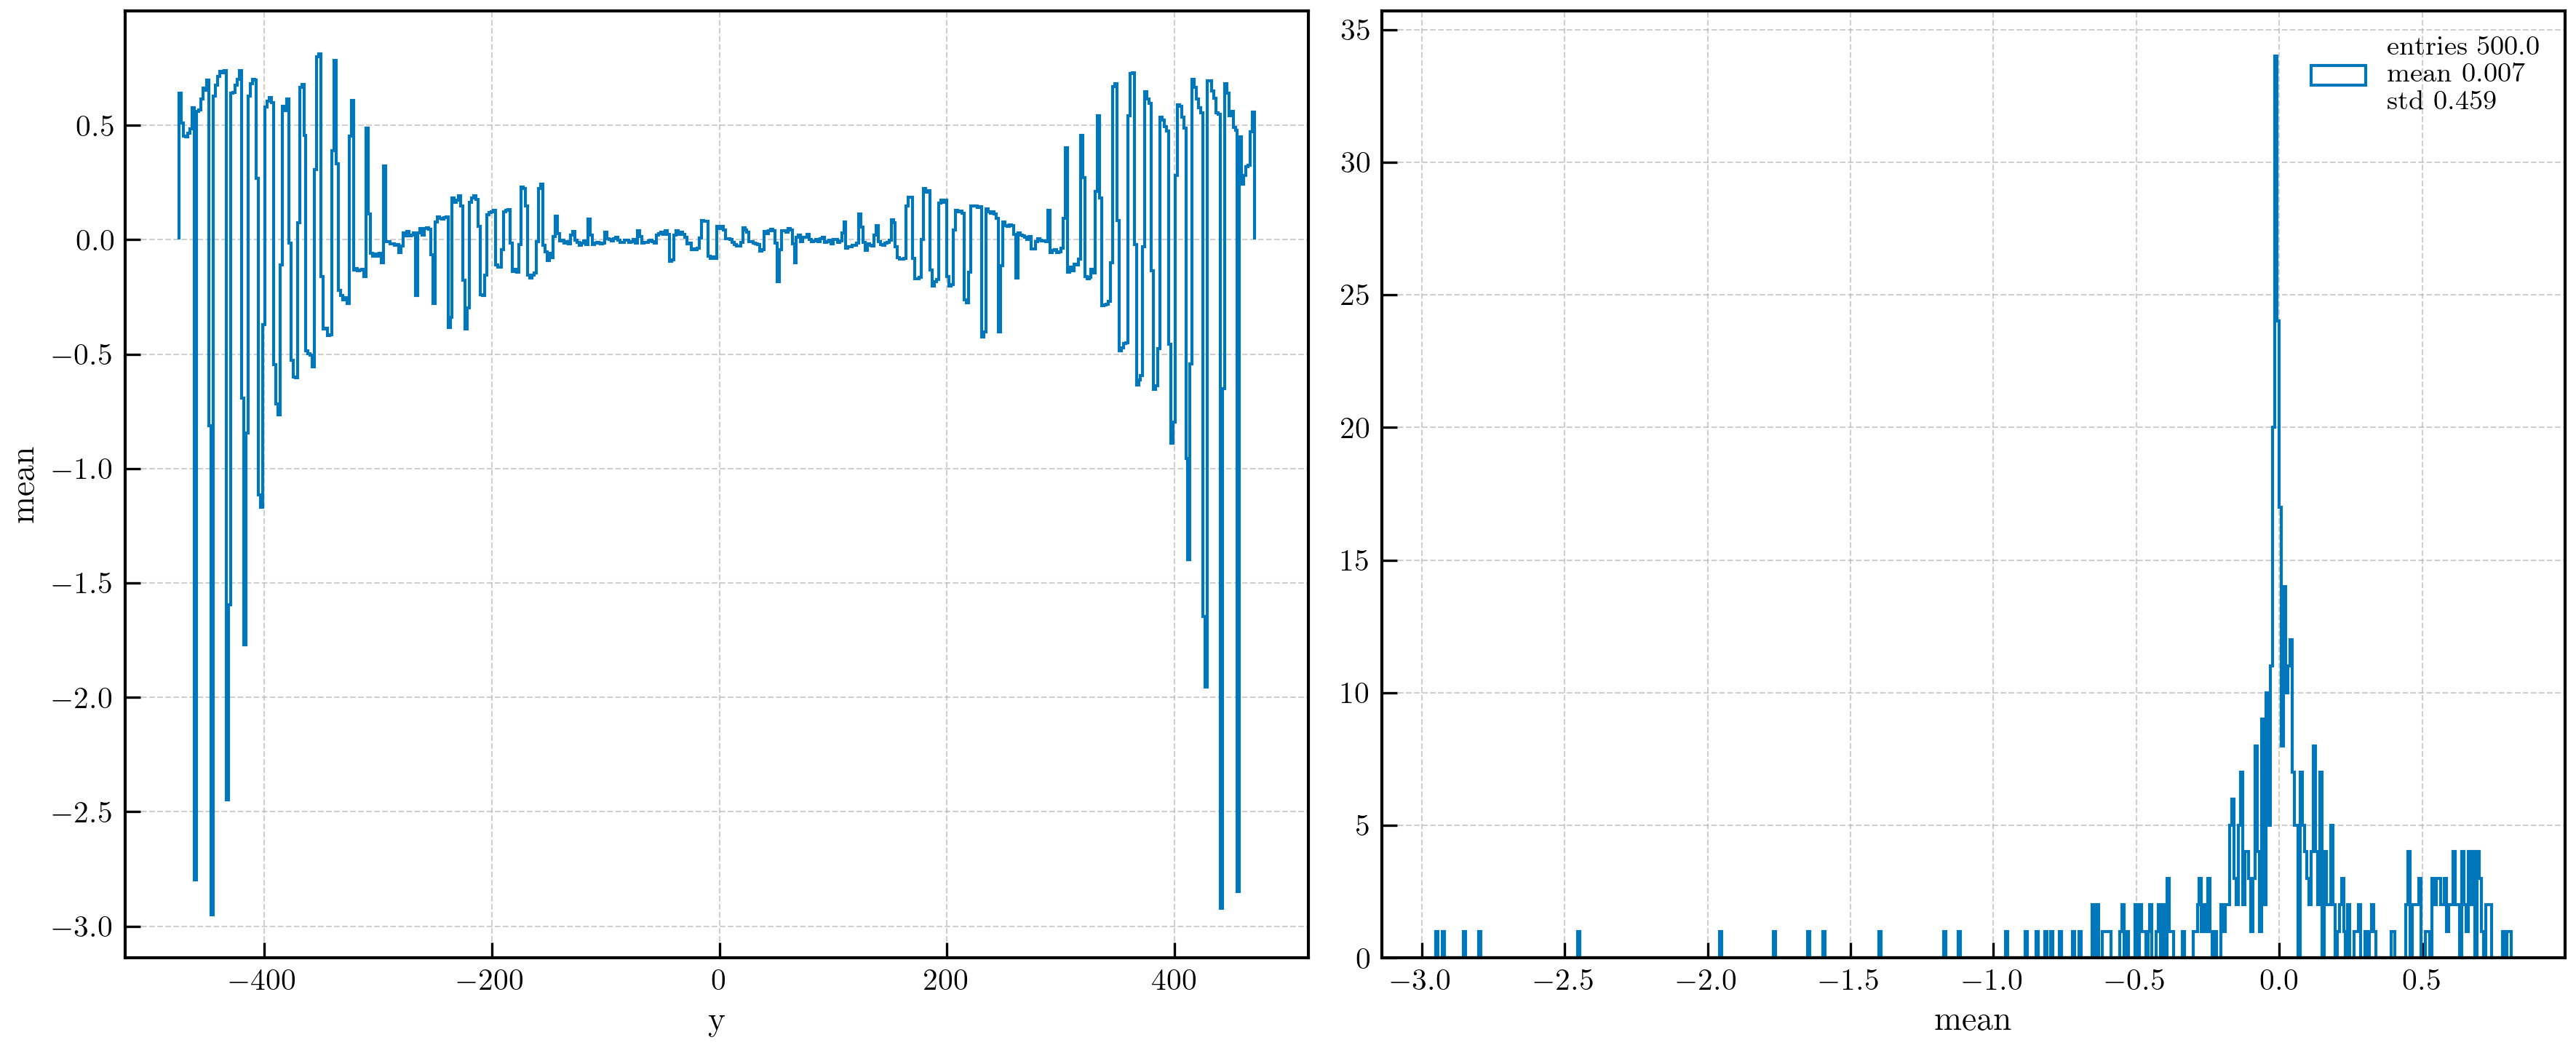

In [119]:
dene = cene_3 - cene_1
xsel = ~np.isnan(dene)
xdf = pd.DataFrame({'x' : cdf[xsel].X, 'y' : cdf[xsel].Y, 'dtime' : cdf[xsel].DT, 'energy': dene[xsel]})
krtool.plot_xydt_energy_profiles(xdf, nbins = 500)

## Compare energy resolition vs dtime, radius

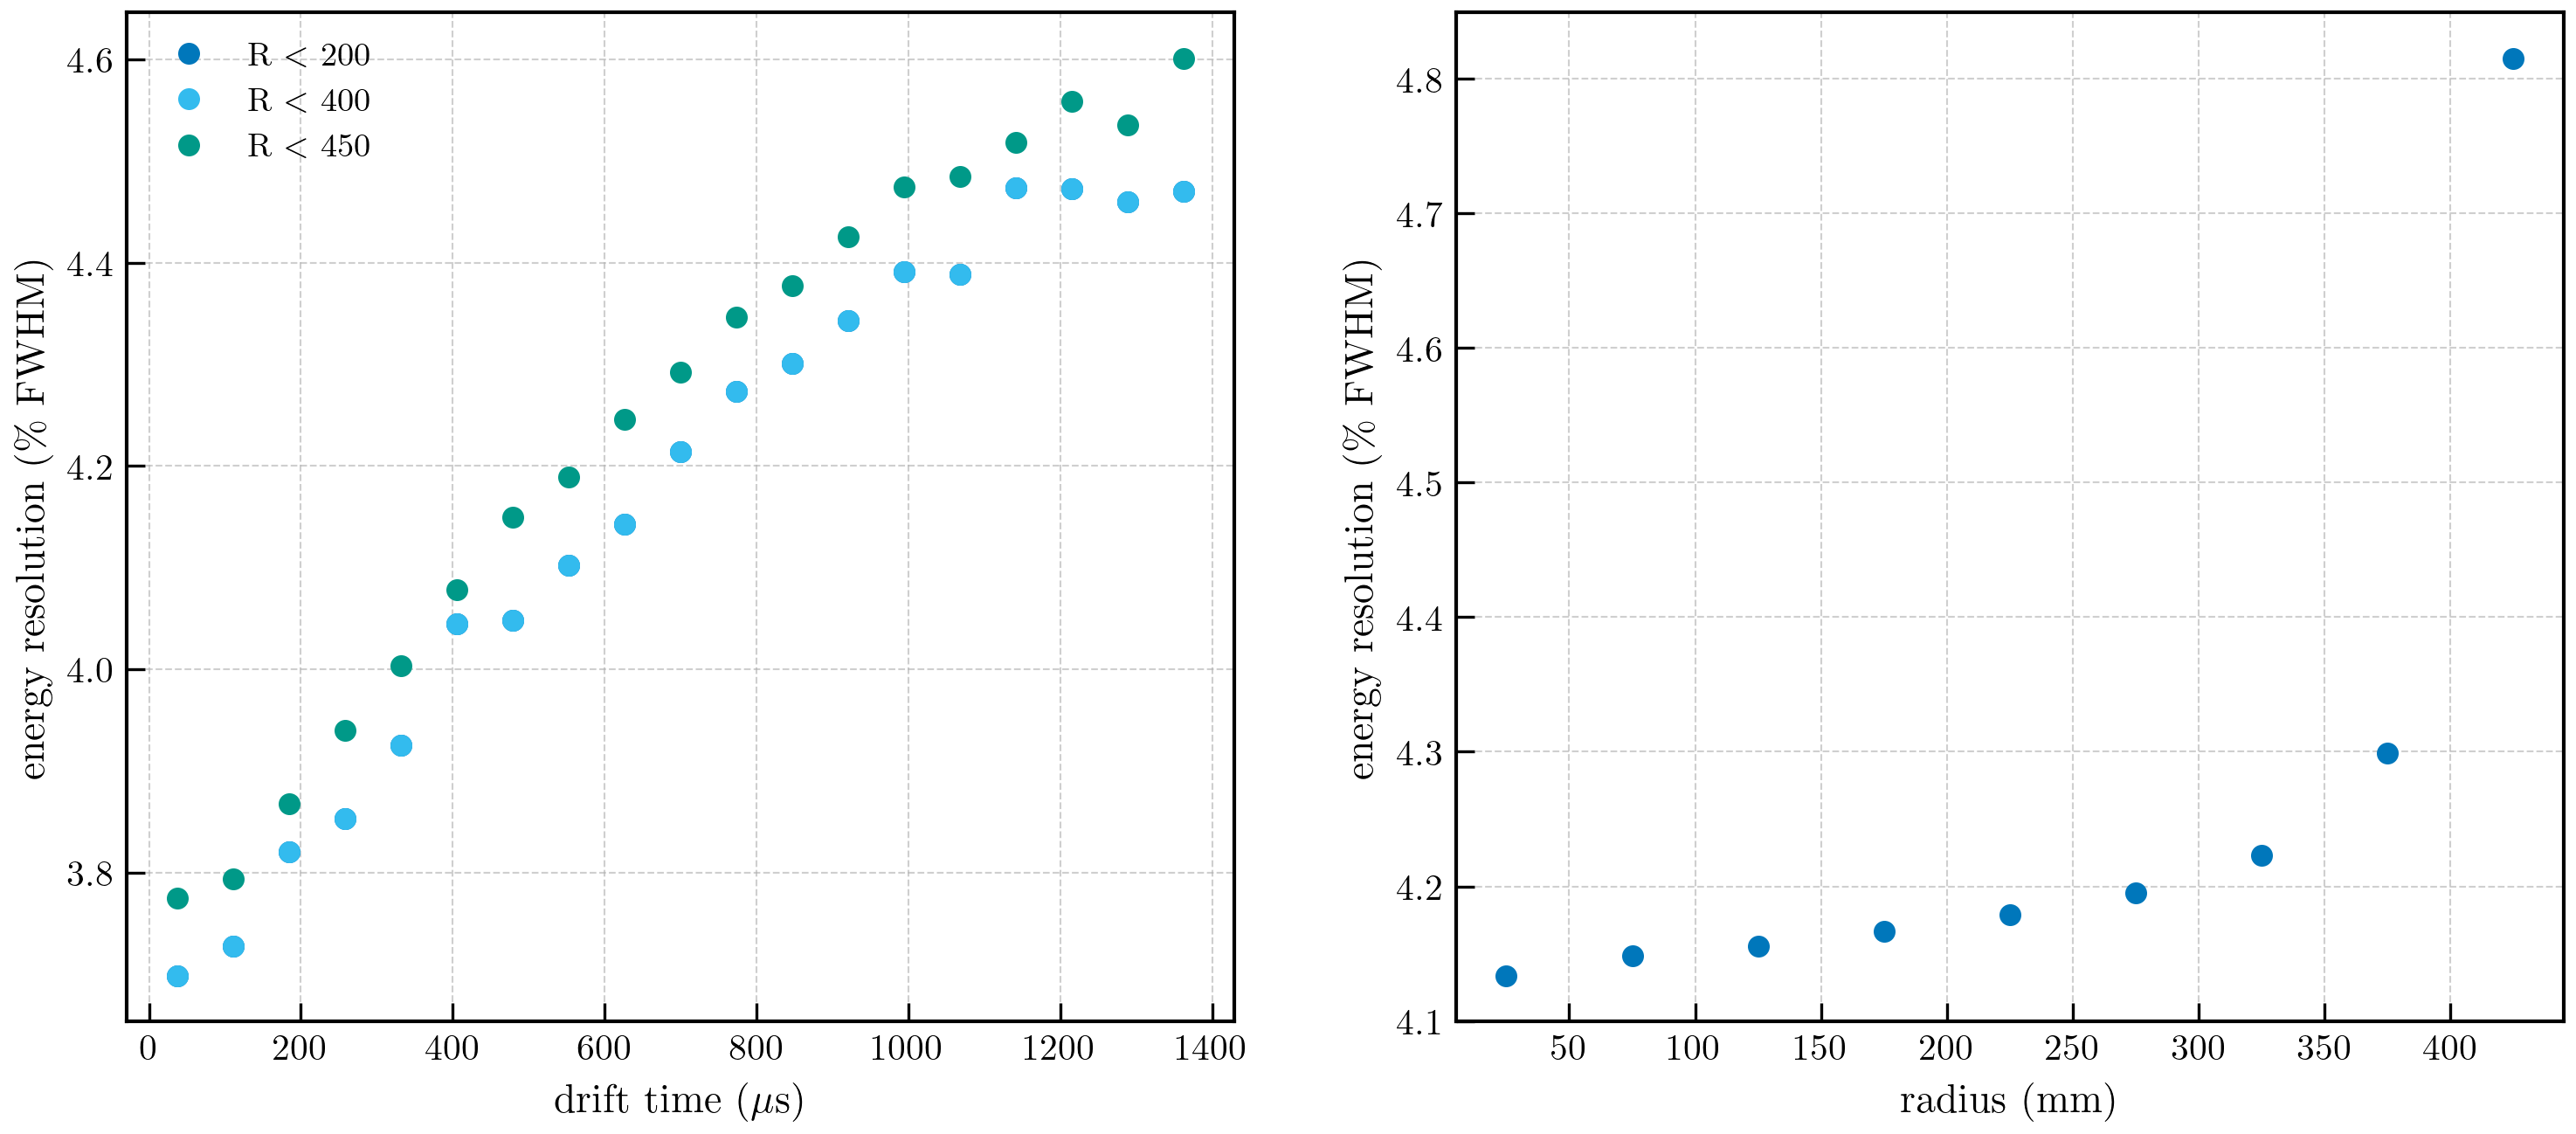

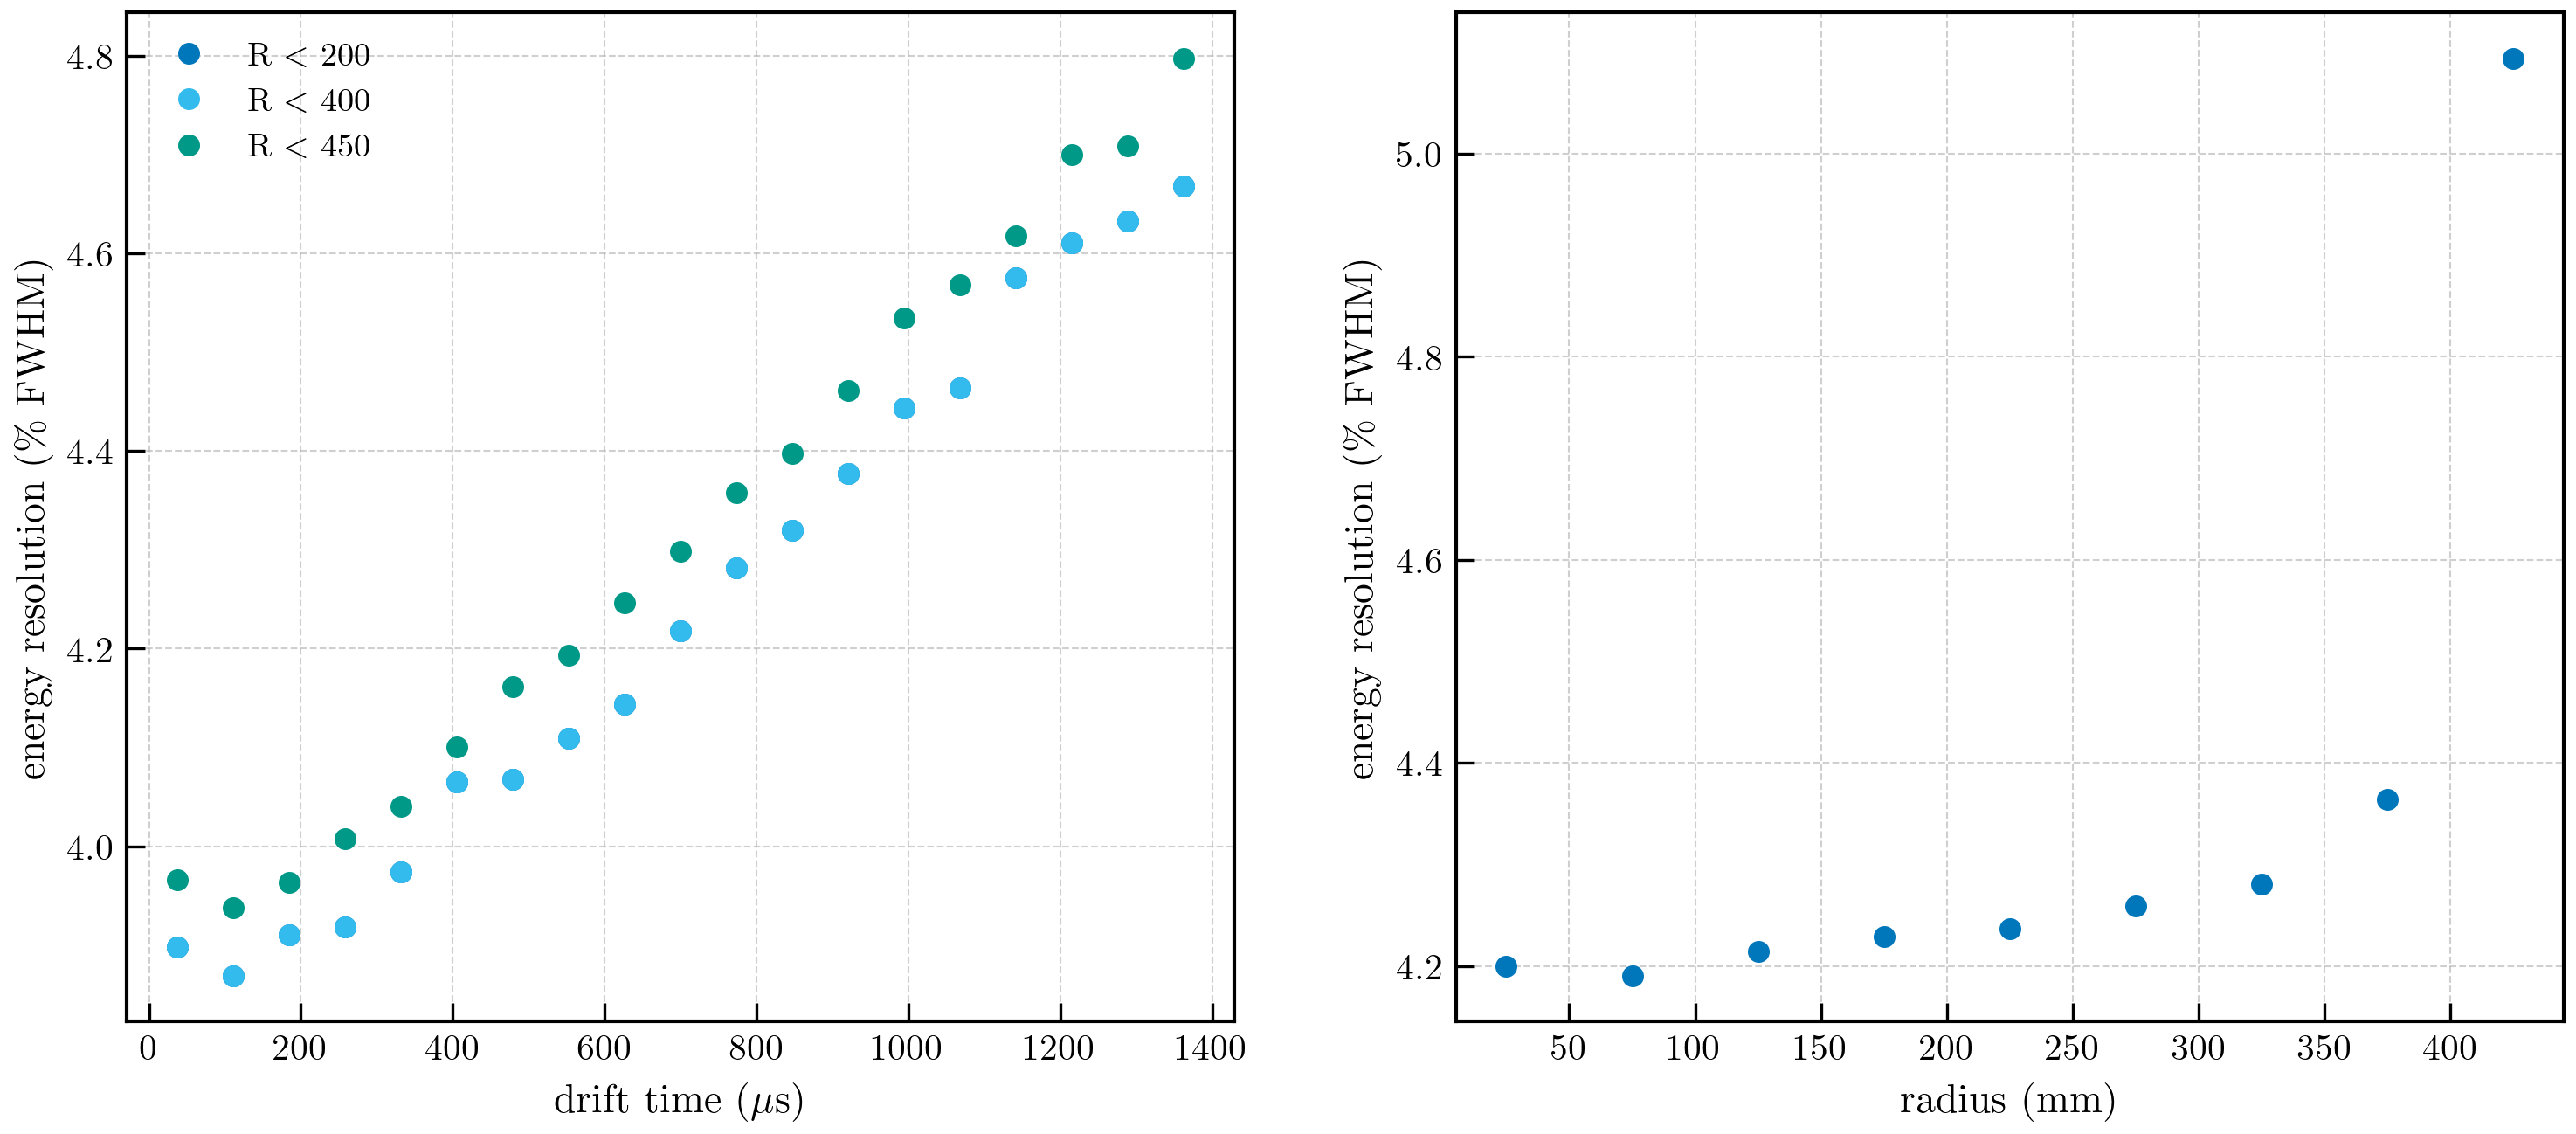

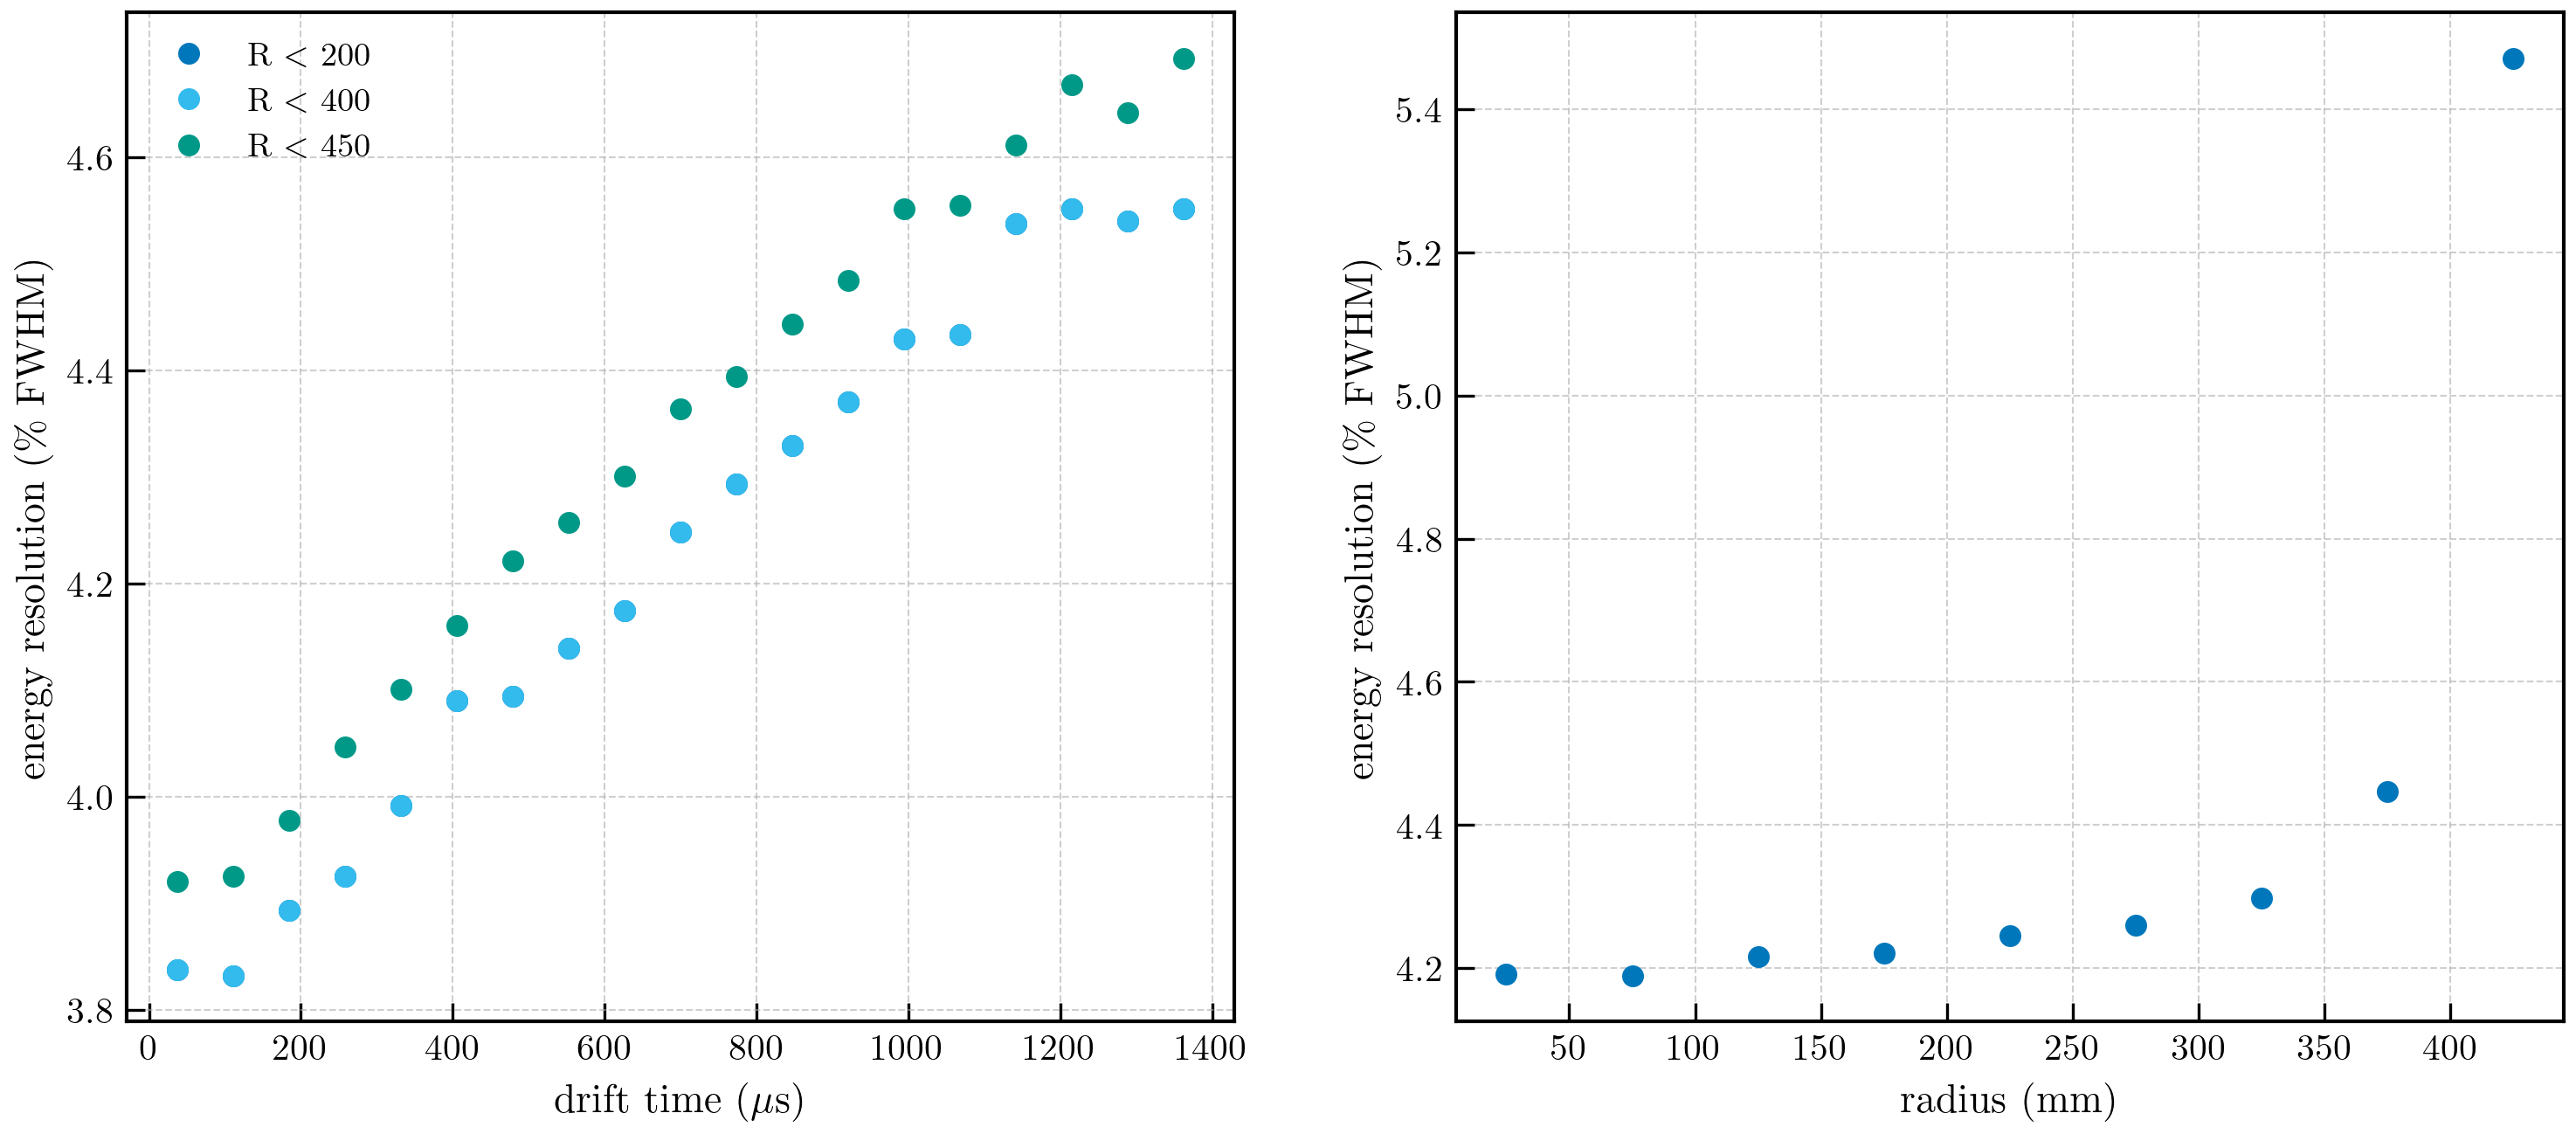

In [135]:
df_ = pd.DataFrame
xsel = ~np.isnan(cene_1)
df1 = df_({'x': cdf.X[xsel], 'y' : cdf.Y[xsel], 'dtime': cdf.DT[xsel], 'r' : cdf.R[xsel], 'energy' : cene_1[xsel]})
xsel = ~np.isnan(cene_3)
df2 = df_({'x': cdf.X[xsel], 'y' : cdf.Y[xsel], 'dtime': cdf.DT[xsel], 'r' : cdf.R[xsel], 'energy' : cene_2[xsel]})
xsel = ~np.isnan(cene_3)
df3 = df_({'x': cdf.X[xsel], 'y' : cdf.Y[xsel], 'dtime': cdf.DT[xsel], 'r' : cdf.R[xsel], 'energy' : cene_3[xsel]})


krn100.plot_eres_in_regions(df1)
krn100.plot_eres_in_regions(df2)
krn100.plot_eres_in_regions(df3)

In [136]:
def plot_eres_in_regions(cdfs):

    dtbins = np.linspace(0, 1400, 15)

    def res_(cdf):
        ress = []
        for rmax in (200, 400, 450):
            usel = ut.in_range(cdf.r, (0, rmax))
            ires = krn100.eres_in_bins(cdf.energy[usel], cdf.dtime[usel], dtbins)
            ress.append(ires)
        return ress
    
    rads = np.linspace(0, 450, 40)

    cv = pltext.canvas(4, 2)
    cv(1)
    labels = ['Kr map LT map', 'Kr map LT unique', 'Kr map 3D']
    for i, cdf in enumerate(cdfs):
        ress = res_(cdf)
        cv(1); plt.plot(ut.centers(dtbins), ress[0], marker = 'o', linestyle = '-', label = labels[i] + r", R $<$ 200" );
        cv(2); plt.plot(ut.centers(dtbins), ress[0], marker = 'o', linestyle = '-', label = labels[i] + r", R $<$ 400" );
        cv(3); plt.plot(ut.centers(dtbins), ress[1], marker = 'o', linestyle = '-', label = labels[i] + r", R $<$ 450");
    cv(1); plt.legend(); plt.xlabel(r"drift time ($\mu$s)"); plt.ylabel("energy resolution (\% FWHM)");
    cv(2); plt.legend(); plt.xlabel(r"drift time ($\mu$s)"); plt.ylabel("energy resolution (\% FWHM)");
    cv(3); plt.legend(); plt.xlabel(r"drift time ($\mu$s)"); plt.ylabel("energy resolution (\% FWHM)");

    rrs   = np.linspace(0, 450, 40)
    for i, cdf in enumerate(cdfs):
        ress2 = krn100.eres_in_bins(cdf.energy, cdf.r, rrs)
        cv(4)
        plt.plot(ut.centers(rrs), ress2, marker = 'o', linestyle = '-', label = labels[i]);
    plt.xlabel(r"radius (mm)"); plt.ylabel("energy resolution (\% FWHM)"); plt.legend();


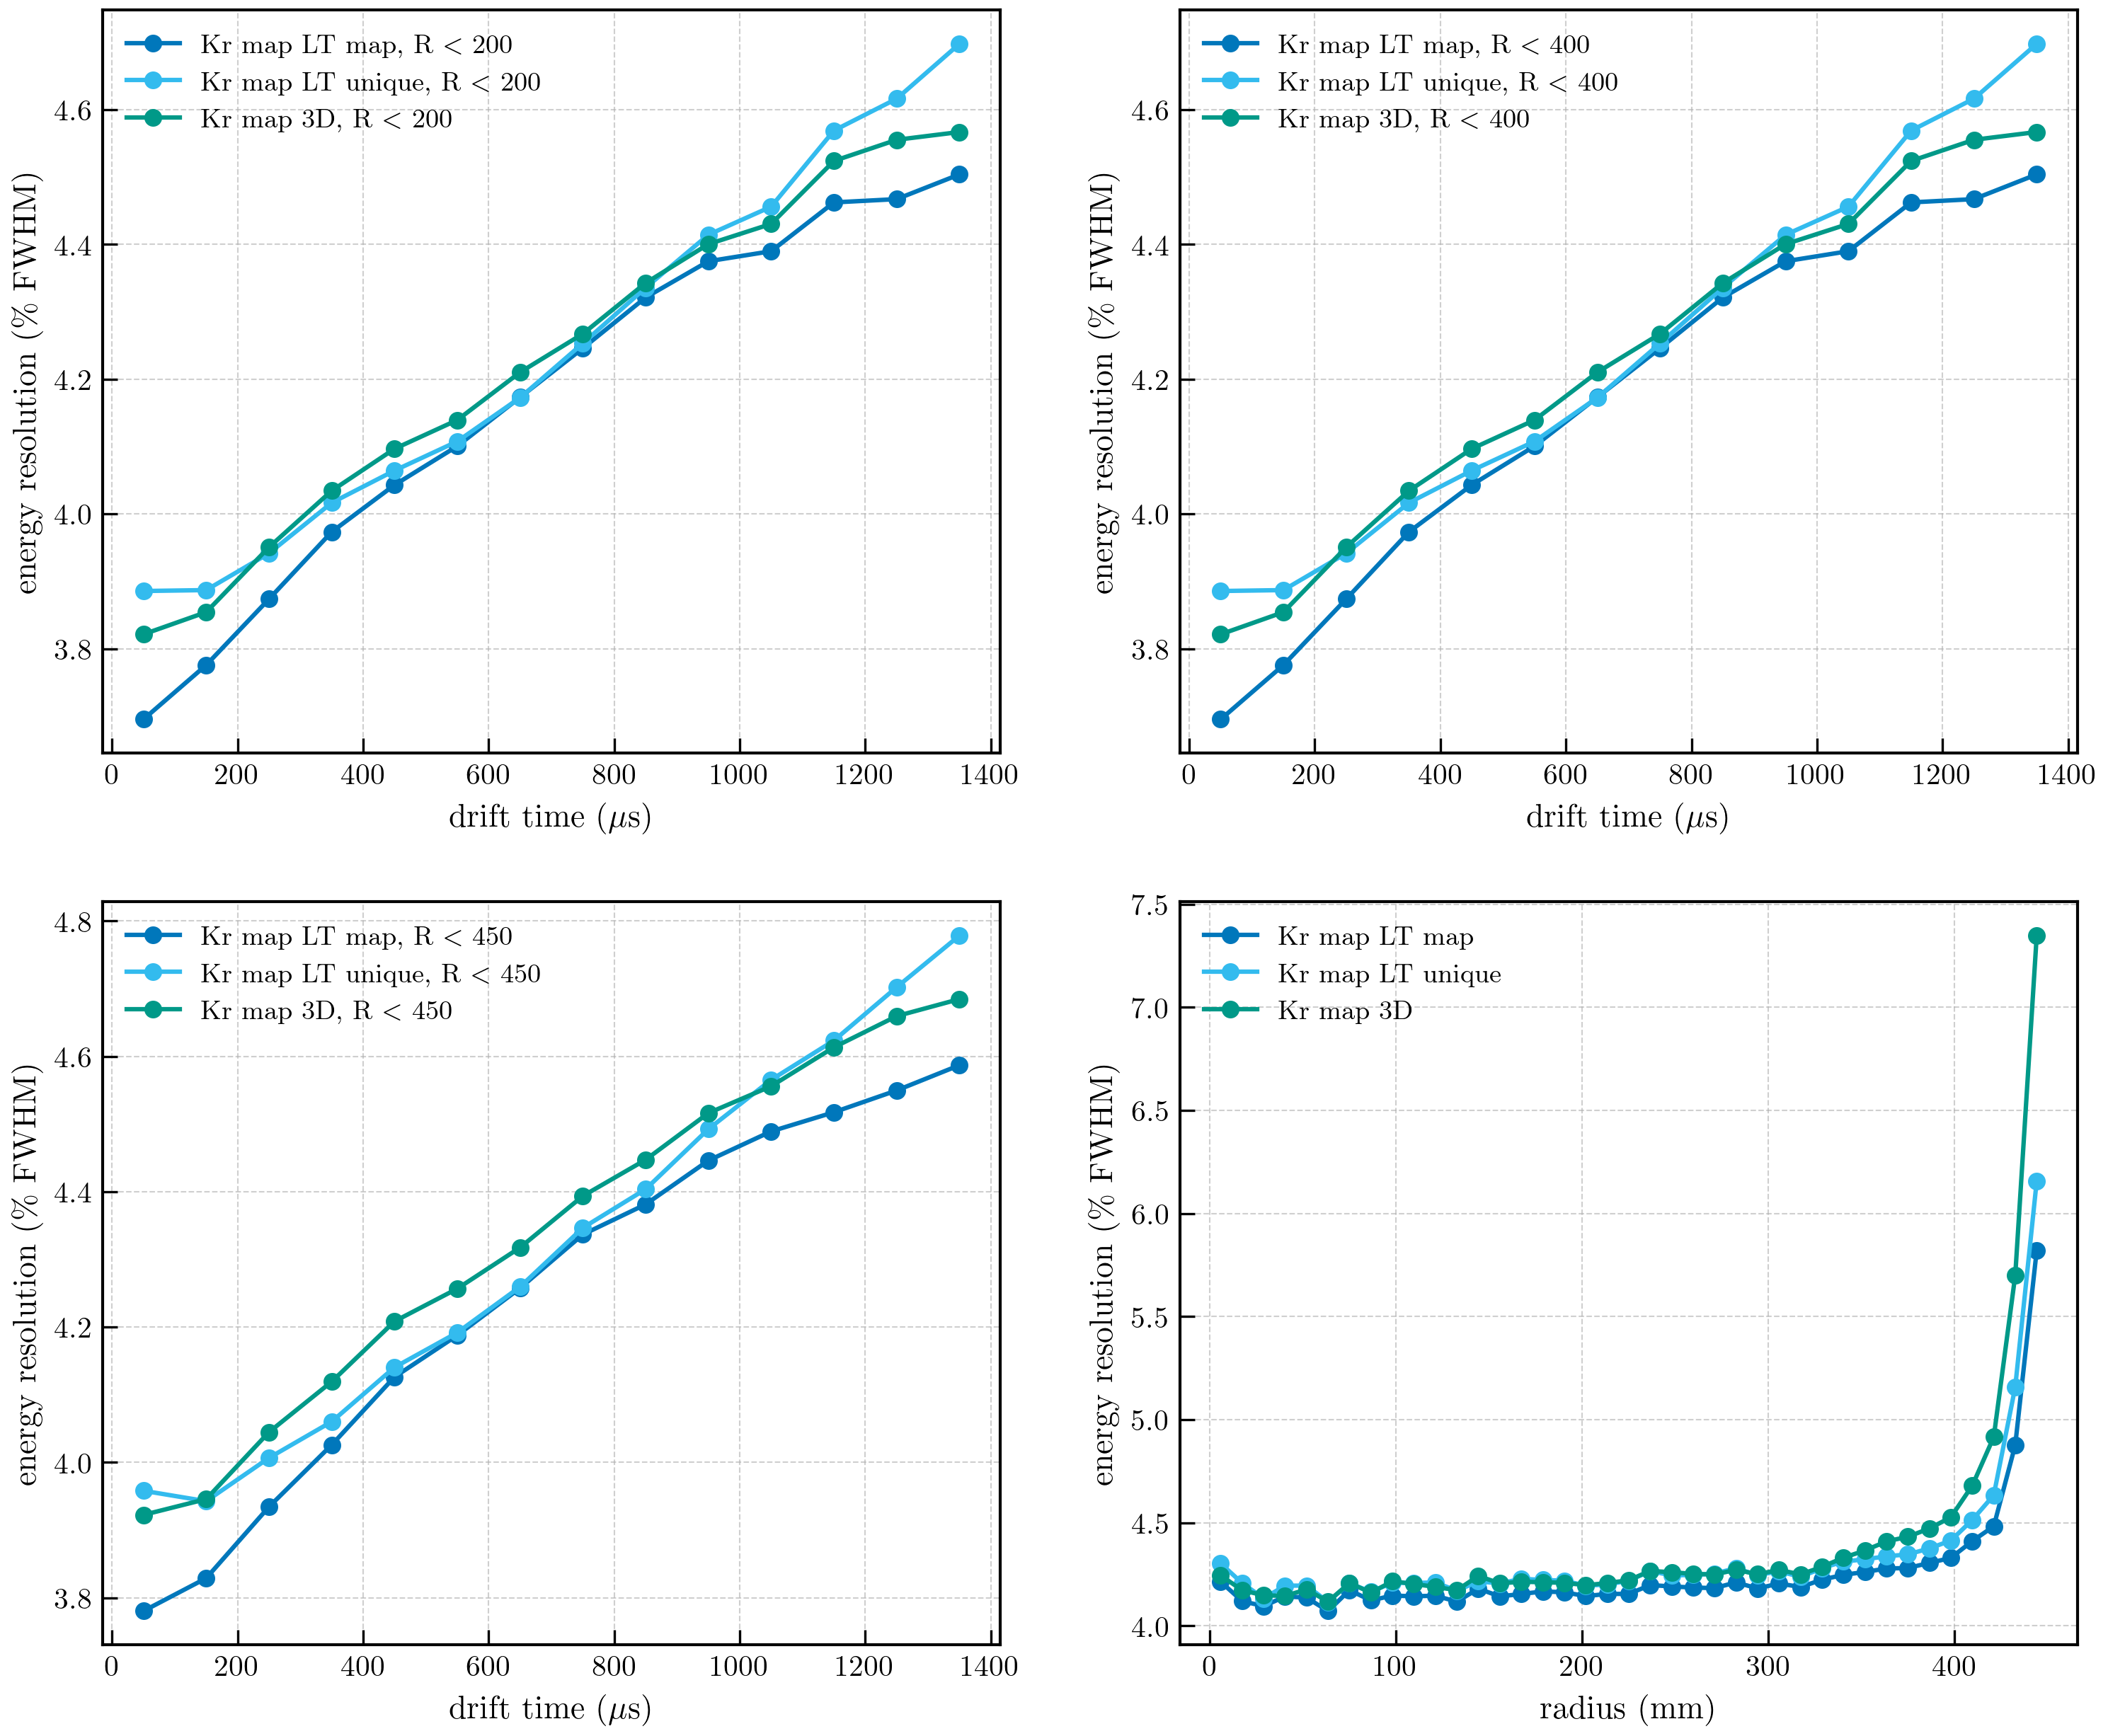

In [137]:
plot_eres_in_regions([df1, df2, df3])

## Compare now with 5 mm pitch

In [123]:
counts_min = 40
pitch      = 5.00
xmin       = -489.825
#xbins      = np.arange(xmin-pitch, -xmin + pitch, pitch)
xbins      = np.arange(xmin, -xmin + pitch, pitch)
bins       = (xbins, xbins) 
print('number of bins ', len(xbins), ', range : ', xbins[0], ', ', xbins[-1])

number of bins  197 , range :  -489.825 ,  490.175


In [124]:
krf, res_1 = krtool.krmap((cdf.X, cdf.Y), cdf.DT, cdf.S2e, bins = bins)
cene_1     = krtool.krmap_scale((cdf.X, cdf.Y), cdf.DT, cdf.S2e, krf, scale = 41.5)

In [125]:
k2d, res_2 = krtool.krmap_ltunique((cdf.X, cdf.Y), cdf.DT, cdf.S2e, bins = bins, rmax = 350., boost = True)
cene_2     = krtool.krmap_ltunique_scale((cdf.X, cdf.Y), cdf.DT, cdf.S2e, k2d, scale = 41.5)

In [126]:
k3d, res_3 = prof.profile((cdf.X, cdf.Y, cdf.DT), cdf.S2e, bins = (68, 68, 10)) 
cene_3     = prof.profile_scale((cdf.X, cdf.Y, cdf.DT), cdf.S2e, k3d, 41.5)

In [127]:
df_ = pd.DataFrame
xsel = ~np.isnan(cene_1)
df1 = df_({'x': cdf.X[xsel], 'y' : cdf.Y[xsel], 'dtime': cdf.DT[xsel], 'r' : cdf.R[xsel], 'energy' : cene_1[xsel]})
xsel = ~np.isnan(cene_3)
df2 = df_({'x': cdf.X[xsel], 'y' : cdf.Y[xsel], 'dtime': cdf.DT[xsel], 'r' : cdf.R[xsel], 'energy' : cene_2[xsel]})
xsel = ~np.isnan(cene_3)
df3 = df_({'x': cdf.X[xsel], 'y' : cdf.Y[xsel], 'dtime': cdf.DT[xsel], 'r' : cdf.R[xsel], 'energy' : cene_3[xsel]})


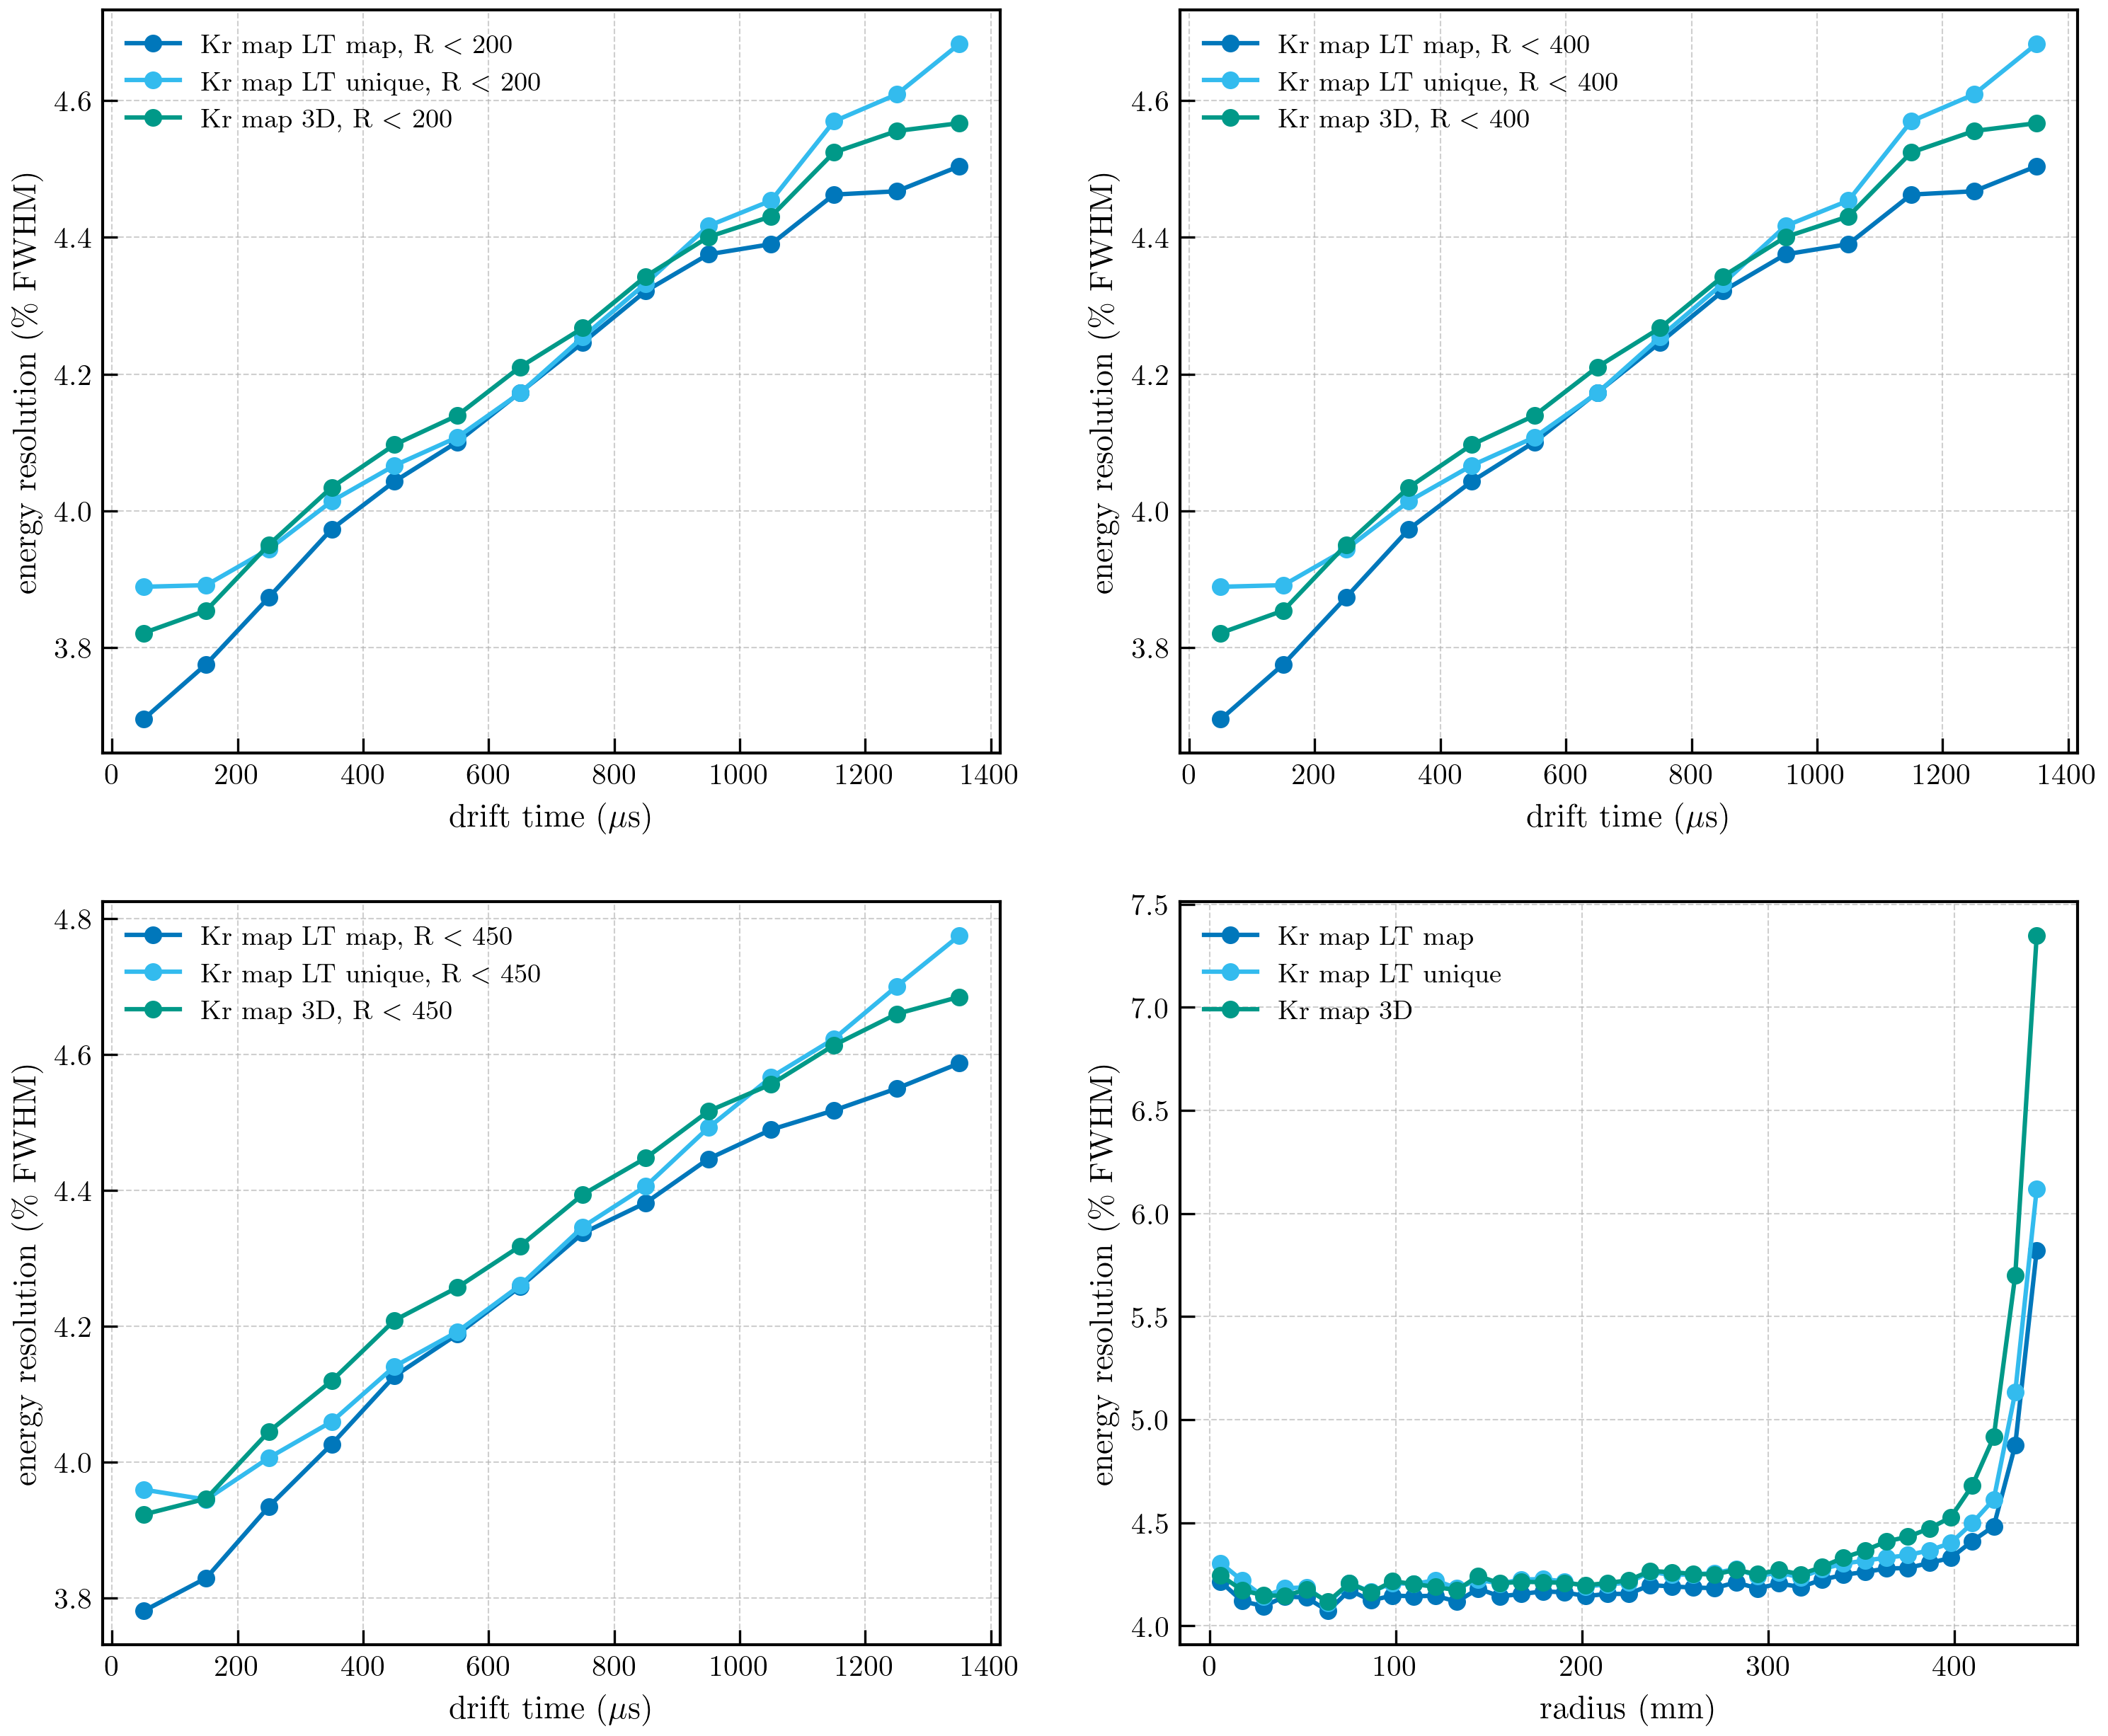

In [128]:
plot_eres_in_regions([df1, df2, df3])